
# Generalized Linear Models
### When the straight line meets counts, probabilities, and positive skew

---

> *"All models are wrong, but some are useful — and some are only useful once you generalise them."*
> — after George E. P. Box

---

Linear regression, which we learned to love in Part 2, is a beautiful instrument tuned to a specific kind of data: continuous, symmetric, homoscedastic responses with approximately normal residuals. Most ecological responses fail at least one of those requirements. Counts cannot be negative and grow more variable as they grow larger. Binary outcomes live on the interval $[0, 1]$ and have variance that depends systematically on their mean. Biomass is strictly positive and right-skewed. Force-fitting linear regression to any of these — as generations of ecologists did, for want of better tools — produces models that predict impossible values, underestimate uncertainty, and sometimes draw the wrong conclusions entirely.

The **generalised linear model** (GLM), introduced by John Nelder and Robert Wedderburn in a landmark 1972 paper, fixed all of this at once. Their insight was almost unreasonably elegant. They noticed that linear regression, logistic regression, Poisson regression, and gamma regression — methods that had been developed independently for decades and taught as four unrelated techniques — were actually four special cases of a single mathematical framework. All four could be written as a *linear predictor* ($\beta_0 + \beta_1 x_1 + \ldots$), a *response distribution* from the exponential family (normal, Bernoulli, Poisson, gamma), and a *link function* translating between them. Nelder and Wedderburn's unified algorithm — iteratively reweighted least squares — fit all four at once. Modern statistical practice is unthinkable without this unification.

By the end of this section you will command the GLM toolkit with fluency. You will know which family matches which ecological response, how to fit and interpret each one, what an offset is and why count models need them, how to diagnose the overdispersion that plagues ecological count data, and when to reach for a gamma regression instead of log-transforming your response. The techniques here — link functions, deviance, the exponential family — will return throughout the Machine Learning topic: logistic regression in Part 5 is the binomial GLM standing alone; MaxEnt in Part 12 is a Poisson GLM in disguise; random forests and gradient boosting inherit their loss functions from GLM theory. Invest the time here and the rest of the Machine Learning concepts become noticeably easier.

#### Topics covered

1. Why linear regression is not enough — ecological counter-examples
2. Nelder and Wedderburn's 1972 unification — the three components of a GLM
3. The exponential family and why it matters
4. Link functions — what they do and how to choose one
5. Poisson regression for count data, with offsets for survey effort
6. Interpreting Poisson coefficients as rate ratios
7. Overdispersion — the quiet killer of ecological count models
8. Negative binomial regression as the standard fix
9. Gamma regression for strictly-positive continuous data
10. A preview of binomial regression (notebook 05 covers it in full)
11. Model comparison with AIC and the deviance
12. Residual diagnostics for GLMs
13. A cheat-sheet mapping ecological responses to families and links

#### R packages required

```r
install.packages(c("tidyverse", "patchwork", "showtext",
                   "scales", "broom", "MASS", "vegan"))
```

The ecological datasets we will use in this page:

- **`vegan::BCI`** — A 50-plot tree census from Barro Colorado Island, Panama, part of the Smithsonian's ForestGEO global network of large tropical-forest dynamics plots. The full dataset records every tree ≥ 10 cm in diameter, by species, in 50 one-hectare plots across the island. The BCI plot was established by Stephen Hubbell and colleagues in 1980 and is the most-studied tropical forest in the world. We use the per-plot counts of the abundant understorey tree *Faramea occidentalis* and the per-plot environmental variables.

- **`MASS::snails`** — A laboratory experiment on dehydration tolerance in two species of land snails, *Cepaea hortensis* and *Cepaea nemoralis*, conducted by P. M. Zonneveld in 1976. Twenty snails per group were exposed to combinations of relative humidity (60–95 %), temperature (10–20 °C), and exposure time (1–4 weeks); the response is the number of deaths.

- **`datasets::trees`** — Volume, girth and height measurements for 31 felled black cherry (*Prunus serotina*) trees in the Allegheny National Forest, Pennsylvania. Reported in Ryan, Joiner and Ryan (1976) and packaged with R since its earliest releases. A canonical biomass dataset.


### Libraries and visual theme


In [1]:
suppressPackageStartupMessages({
  library(tidyverse)
  library(patchwork)
  library(showtext)
  library(scales)
  library(broom)
  library(MASS)
  library(vegan)
})

# dplyr::select takes precedence over MASS::select
select <- dplyr::select

options(repr.plot.width = 13, repr.plot.height = 7.5, repr.plot.res = 180)

font_add_google("Playfair Display", "playfair")
font_add_google("Montserrat",       "mont")
font_add_google("Fira Code",        "fira")
showtext_auto()

In [2]:
# Custom theme for all figures
theme_ml <- function(base_size = 11) {
  theme_minimal(base_family = "mont", base_size = base_size) +
    theme(
      plot.background   = element_rect(fill = "#fafafa", colour = NA),
      panel.background  = element_rect(fill = "#ffffff", colour = NA),
      panel.grid.major  = element_line(colour = "#eeeeee", linewidth = 0.4),
      panel.grid.minor  = element_blank(),
      panel.border      = element_rect(colour = "#dddddd", fill = NA, linewidth = 0.5),
      plot.title        = element_text(family = "playfair", face = "bold",
                                       size = base_size * 1.6, colour = "#1a1a2e",
                                       margin = margin(b = 6)),
      plot.subtitle     = element_text(size = base_size * 0.95, colour = "#4a4a6a",
                                       margin = margin(b = 10)),
      plot.caption      = element_text(size = base_size * 0.72, colour = "#9a9ab0",
                                       hjust = 0, margin = margin(t = 10)),
      axis.title        = element_text(colour = "#1a1a2e", size = base_size * 0.9,
                                       face = "bold"),
      axis.text         = element_text(colour = "#5a5a7a", size = base_size * 0.82),
      legend.position   = "bottom",
      legend.title      = element_text(face = "bold", colour = "#1a1a2e",
                                       size = base_size * 0.85),
      legend.text       = element_text(colour = "#4a4a6a", size = base_size * 0.8),
      strip.background  = element_rect(fill = "#1a1a2e", colour = NA),
      strip.text        = element_text(colour = "white", face = "bold",
                                       size = base_size * 0.85),
      plot.margin       = margin(16, 20, 12, 16)
    )
}

# Colour palettes
PalDiscrete   <- c("#e63946", "#457b9d", "#2a9d8f", "#e9c46a",
                   "#f4a261", "#6c5ce7", "#264653", "#b5838d")
PalDiverging  <- c("#2166ac", "#92c5de", "#f7f7f7", "#f4a582", "#d6604d")
PalSequential <- c("#fff9f0", "#fdd49e", "#fdbb84", "#fc8d59", "#d7301f", "#7f0000")

---
## Where the straight line breaks

Three ecological scenarios will help us see, concretely, where ordinary linear regression runs out of road. Each one is real in the sense that any working ecologist will meet it within their first year in the field, and each one requires a different generalisation of the linear framework.

Imagine first a raptor-migration monitoring project. Each morning, observers stand at viewpoints overlooking a ridge and count the birds crossing overhead during a fixed window of time. The response variable is a **count** — a non-negative integer. Linear regression fit to such data will blithely predict negative counts at unfavourable habitat, will assume the variance is the same whether you are counting two birds or two hundred, and will have residuals that look nothing like a normal distribution.

Imagine next a pond-occupancy survey for great crested newts. Each pond is either occupied or not, a binary outcome. The response is a **probability** — bounded in the interval $[0, 1]$. Linear regression will happily predict probabilities of 1.3 at the lushest ponds and of $-0.2$ at the poorest, neither of which means anything biologically.

Imagine third an above-ground biomass inventory of tropical trees. Biomass is **strictly positive and right-skewed** — a long tail of emergent giants sits above a dense cluster of understorey saplings — and its variance grows with the mean, because a ten-tonne tree has far more room to vary than a one-kilogram sapling. Linear regression fit to raw biomass will have residuals that are not normal and variance that is not constant. Log-transforming the response helps, but introduces its own problems with back-transformation bias.

These three scenarios motivate three distinct GLM families: **Poisson** for counts, **binomial** for binary outcomes and proportions, and **gamma** for positive continuous data. The figure below shows what goes wrong when we try to use ordinary `lm()` on each. *We use small synthetic datasets here purely to make the failure modes visible — every other model in this notebook is fitted to real, published ecological data.*

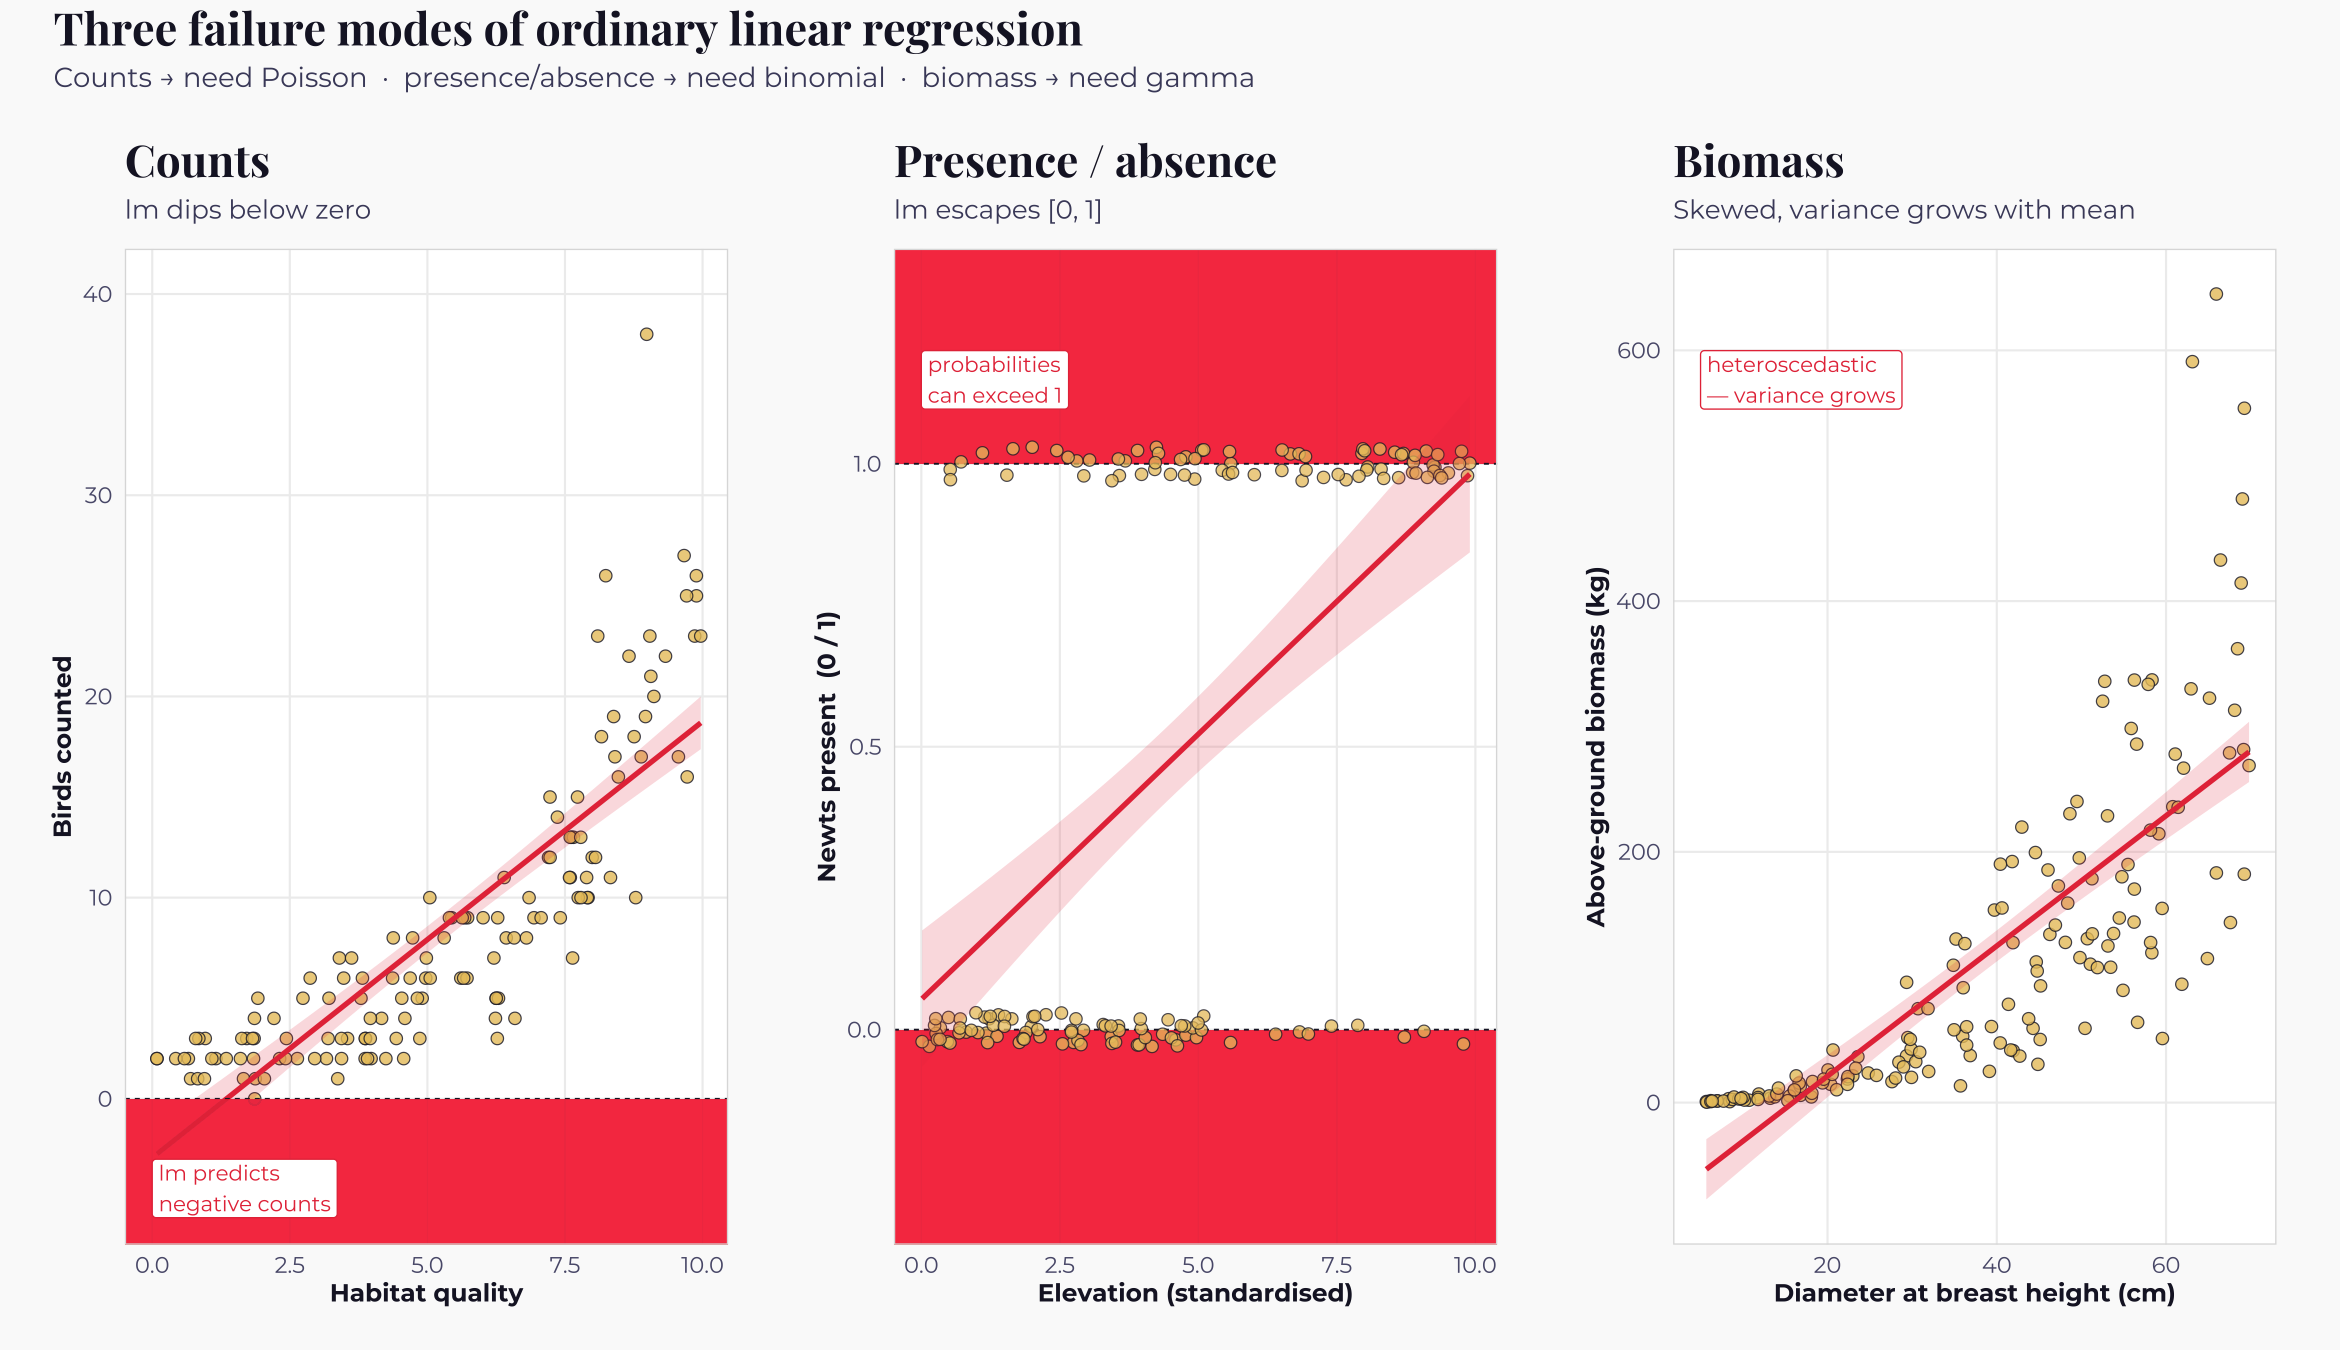

---
## Nelder and Wedderburn's unification

In the late 1960s John Nelder — then at Rothamsted Experimental Station — and his postdoctoral colleague Robert Wedderburn were staring at what looked like a zoo of regression methods. Linear regression for continuous responses. Probit and logistic regression for binary responses. Poisson log-linear models for counts. Gamma regression for positive data. Each method had its own fitting algorithm, its own convergence criteria, its own definition of residuals, its own interpretation of goodness-of-fit. Working statisticians had to learn a new toolkit for each new kind of response.

Their 1972 paper in the *Journal of the Royal Statistical Society* showed that these were not separate methods at all. Every one of them could be written as the same three-part structure:

1. A **random component** — the conditional distribution of the response, chosen from the *exponential family*.
2. A **systematic component** — a linear predictor $\eta_i = \beta_0 + \beta_1 x_{1i} + \beta_2 x_{2i} + \ldots$, exactly the same sum of products you already know from linear regression.
3. A **link function** $g(\cdot)$ — a monotonic function that translates between the mean of the response and the linear predictor:

$$
g(\mathbb{E}[y_i]) \;=\; \eta_i.
$$

Change the random component and the link and you get a different member of the family. Keep Gaussian with an identity link and you get `lm()`. Switch to Bernoulli with a logit link and you get logistic regression. Switch to Poisson with a log link and you get Poisson regression for counts. Switch to gamma with a log link and you get gamma regression for biomass. One framework, one algorithm, four (and more) applications.

The fitting algorithm Nelder and Wedderburn devised — **iteratively reweighted least squares** (IRLS) — deserves a mention because it explains why GLMs fit so fast in software even today. IRLS repeatedly applies ordinary least squares to a transformed working response, with observation-specific weights that are updated at each iteration. Convergence is typically achieved in five to ten iterations. When you type `glm()` in R, you are running an IRLS solver whose lineage goes directly back to that 1972 paper.

The figure below captures the unified structure visually. The linear predictor — on the far left — is the same in every panel. The response distribution — on the far right — is different in each. The link function in the middle does the translation.

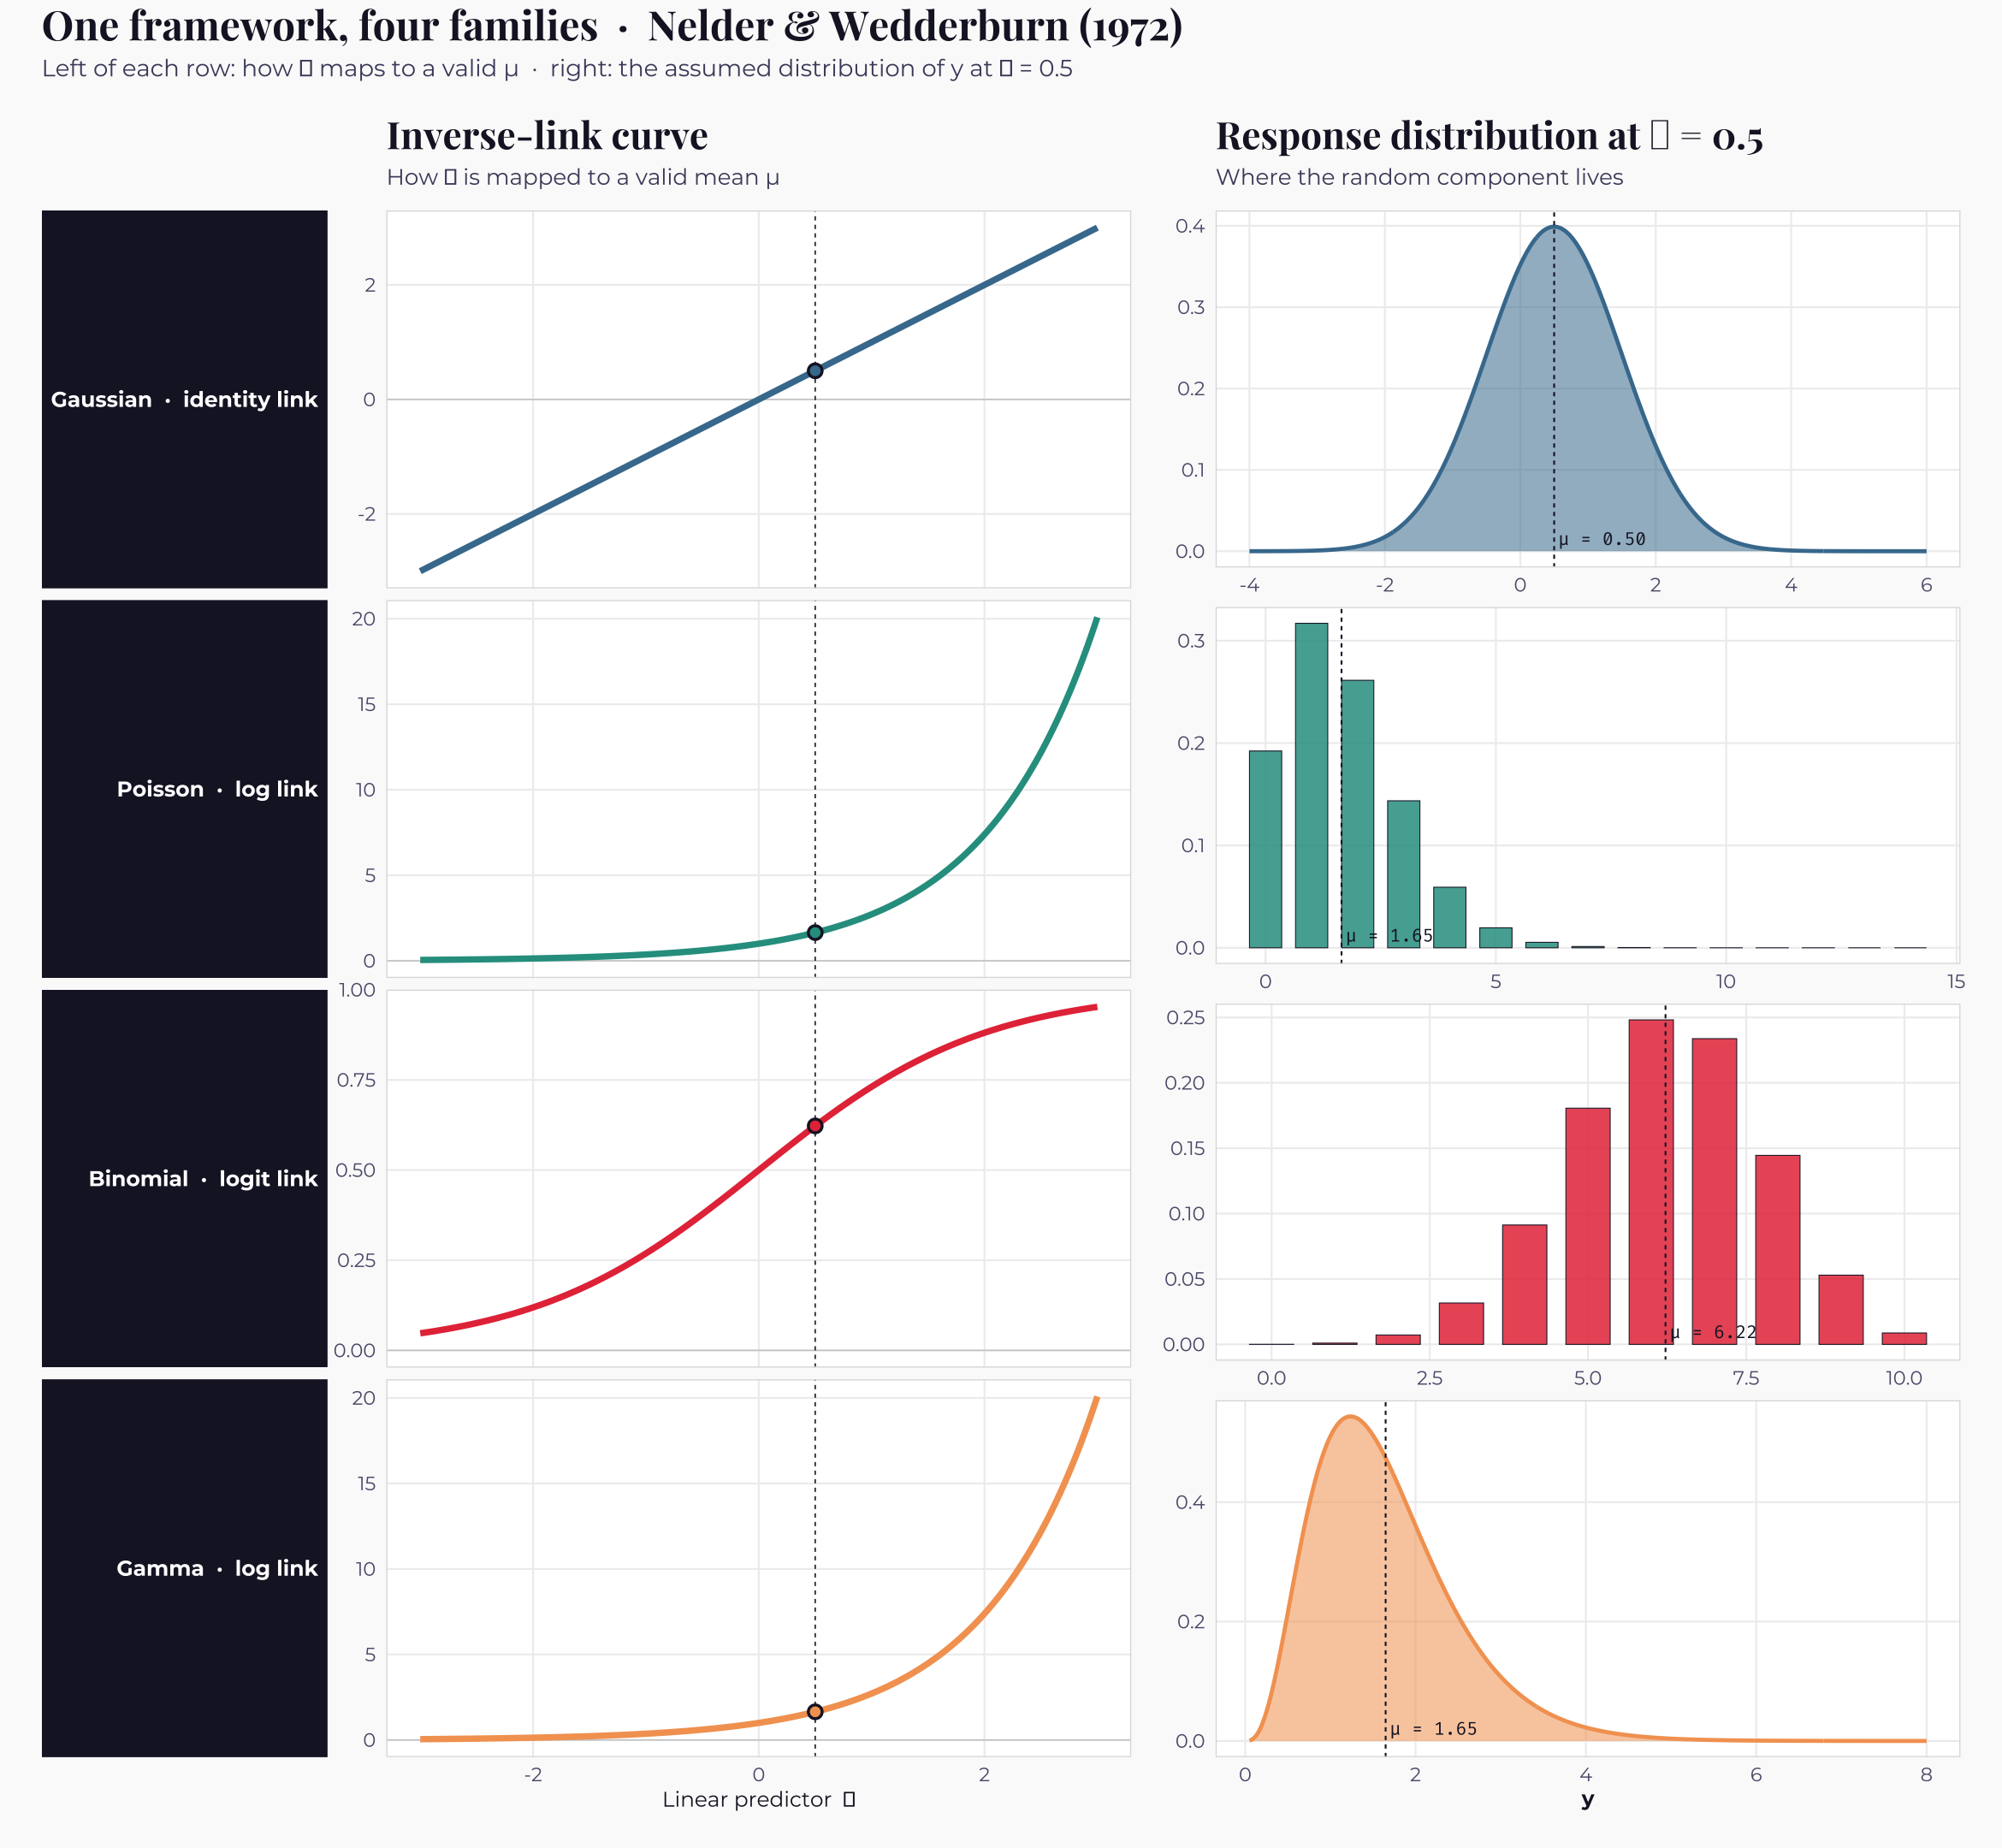


The left column of each row shows the inverse-link function — what the linear predictor $\eta$ gets mapped to in order to become a valid mean for that distribution. For the Gaussian it is the identity function, a straight line: any $\eta$ is a valid mean. For the Poisson it is the exponential, which ensures the mean is always positive. For the binomial it is the logistic function, which squashes any $\eta$ into the interval $[0, 1]$. For the gamma, the log link gives strict positivity like the Poisson, but now the response itself is continuous.

The right column shows, for the particular value $\eta = 0.5$, what distribution the response is assumed to follow. A Gaussian bell. A Poisson pmf clustered at small counts. A binomial pmf over ten trials. A right-skewed gamma density. Changing the row changes *everything on the right*, but the linear predictor on the far left is the same in every case. That is the unification.


---
## The exponential family — why these four and not others?

You may reasonably wonder why Nelder and Wedderburn could unify these four particular distributions and not some arbitrary collection you might dream up. The answer is that all four belong to a mathematical club called the **exponential family**, which shares a specific algebraic structure:

$$
f(y \mid \theta, \phi) \;=\; \exp\!\left\{ \frac{y\theta - b(\theta)}{a(\phi)} \;+\; c(y, \phi) \right\}.
$$

You do not need to memorise this formula. What matters is that every distribution whose density can be written in this form inherits a package of convenient properties. Its mean is $\mu = b'(\theta)$ — the derivative of the $b$ function. Its variance is $\text{Var}(y) = a(\phi)\, b''(\theta)$ — a function of the mean, with a dispersion scaling $\phi$. And — crucially — the same iteratively reweighted least squares algorithm fits any member of the family without modification, using only the first and second derivatives of $b$.

The practical consequence is that, for each family, we have a characteristic **mean-variance relationship** that serves as a sanity check when we decide which family to use. For the Gaussian, the variance is constant and does not depend on the mean at all — this is what the equal-variance assumption in linear regression says. For the Poisson, the variance *equals* the mean: $\text{Var}(y) = \mu$. For the binomial with denominator $n$, the variance is $n\mu(1 - \mu)$ — largest at a probability of 0.5, smallest near 0 or 1. For the gamma, the variance is proportional to the *square* of the mean: $\text{Var}(y) = \phi\mu^2$, so the standard deviation grows linearly with the mean.

Knowing these relationships is the single most practical piece of GLM intuition you can carry. When you see a scatter of counts whose spread grows roughly with the mean, think Poisson. When you see proportions whose variance peaks in the middle and shrinks at the edges, think binomial. When you see positive values whose spread grows with the mean on a multiplicative scale, think gamma. If none of these match, you may need a quasi-likelihood, a negative binomial, or a Tweedie distribution — extensions that live just beyond the GLM house but share the same plumbing.

---
## Poisson regression for count data — *Faramea* on Barro Colorado Island

We turn now to the first and most common GLM application in ecology: regression for count data. Our running example is a real published dataset: the abundance of the understorey tree ***Faramea occidentalis*** across 50 one-hectare plots on **Barro Colorado Island** (BCI), Panama. BCI sits in the middle of the Panama Canal — a forested island that became one when the Chagres River was dammed to flood the canal corridor in the 1910s — and since 1980 it has hosted what is now the most-studied tropical forest plot in the world. The 50-plot grid covers a 1000 × 500 m rectangle with measurements of every tree ≥ 10 cm in diameter. Each plot has been classified by habitat type (`OldHigh`, `OldLow`, `OldSlope`, `Swamp`, `Young`), proximity to a stream (yes / no), and an environmental heterogeneity index. The data ship with the `vegan` package as `BCI` (the species × plot matrix) and `BCI.env` (the environmental covariates).

*Faramea occidentalis* is a small, shade-tolerant Rubiaceae. It is one of the most abundant trees in the understorey but its distribution is uneven — concentrated on well-drained slopes and ridges, sparser on the moister flats and swamps. Our question: can we model its per-plot abundance as a function of habitat type and environmental heterogeneity?

The model we want is:

$$
\log\bigl(\mathbb{E}[y_i]\bigr) \;=\; \beta_0 \;+\; \beta_{\text{habitat}_i} \;+\; \beta_{\text{stream}_i} \;+\; \beta_{\text{EnvHet}} \cdot \text{EnvHet}_i,
\qquad y_i \sim \text{Poisson}(\mu_i),
$$

where $y_i$ is the count of *Faramea* trees in plot $i$, the habitat and stream coefficients are dummy-coded relative to the most common levels, and EnvHet is a continuous heterogeneity index between 0 and 1.

A note on **offsets**: the BCI plots are all 1 hectare, so there is no need to account for variable effort. In studies where survey effort varies — different transect lengths, different observation hours, different bait-station deployment durations — the standard fix is to add an *offset* term, $\log(\text{effort}_i)$, with its coefficient fixed at 1. This forces the model to predict counts proportional to effort:

$$
\log(\mathbb{E}[y_i]) \;=\; \log(\text{effort}_i) \;+\; \text{linear predictor},
$$

which rearranges to a model for the *rate* (counts per unit effort). In R you write `glm(y ~ x + offset(log(effort)), ...)`. We will not need it for BCI but you should know the syntax for when you do.

In [5]:
# Load the BCI tree data and environmental covariates
data(BCI); data(BCI.env)

# Faramea occidentalis is one of the most-studied BCI species.
# Build a working data frame with the count and the relevant covariates.
faramea <- tibble(
  count    = BCI[, "Faramea.occidentalis"],
  habitat  = BCI.env$Habitat,
  stream   = BCI.env$Stream,
  env_het  = BCI.env$EnvHet,
  utm_ew   = BCI.env$UTM.EW,
  utm_ns   = BCI.env$UTM.NS
)

cat("Plots:", nrow(faramea), "  ·  Faramea count range:",
    paste(range(faramea$count), collapse = "–"),
    "  ·  Mean:", round(mean(faramea$count), 1), "\n")
cat("\nHabitat distribution across plots:\n")
print(table(faramea$habitat))
cat("\nFirst six plots:\n")
head(faramea)

Plots: 50   ·  Faramea count range: 7–80   ·  Mean: 34.3 

Habitat distribution across plots:

 OldHigh   OldLow OldSlope    Swamp    Young 
       8       26       12        2        2 

First six plots:


count,habitat,stream,env_het,utm_ew,utm_ns
<int>,<fct>,<fct>,<dbl>,<dbl>,<dbl>
14,OldSlope,Yes,0.6272,625754,1011569
36,OldLow,Yes,0.3936,625754,1011669
39,OldLow,No,0.0000,625754,1011769
39,OldLow,No,0.0000,625754,1011869
22,OldSlope,No,0.4608,625754,1011969
16,OldLow,No,0.0768,625854,1011569


In [6]:
# Fit the Poisson GLM
fit_pois <- glm(
  count ~ habitat + stream + env_het,
  family = poisson(link = "log"),
  data   = faramea
)
summary(fit_pois)


Call:
glm(formula = count ~ habitat + stream + env_het, family = poisson(link = "log"), 
    data = faramea)

Coefficients:
                 Estimate Std. Error z value Pr(>|z|)    
(Intercept)      4.095102   0.056889  71.984  < 2e-16 ***
habitatOldLow   -0.517322   0.060213  -8.592  < 2e-16 ***
habitatOldSlope -1.008573   0.082979 -12.155  < 2e-16 ***
habitatSwamp    -0.510131   0.142327  -3.584 0.000338 ***
habitatYoung    -0.080495   0.113520  -0.709 0.478275    
streamYes       -0.004789   0.084142  -0.057 0.954610    
env_het         -0.260685   0.111698  -2.334 0.019604 *  
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1

(Dispersion parameter for poisson family taken to be 1)

    Null deviance: 371.78  on 49  degrees of freedom
Residual deviance: 176.85  on 43  degrees of freedom
AIC: 453.78

Number of Fisher Scoring iterations: 4


The output mirrors the `lm()` summary we saw in Part 2 but with three new features worth noting. First, the **Coefficients** column no longer reports a *t*-value; it reports a **z-value** computed against the normal distribution, because for GLMs the sampling distribution of the estimator is normal asymptotically rather than exactly-*t*. Second, two new summary quantities appear near the bottom: the **null deviance** and the **residual deviance**. These are the GLM analogue of total sum of squares and residual sum of squares, and the difference between them — analogous to the explained sum of squares — is what the overall goodness-of-fit test evaluates. Third, there is no $R^2$. Generalised linear models do not have a universally-agreed $R^2$, though several "pseudo-$R^2$" quantities exist and we will introduce them in Part 5.

The ecological reading is direct. The reference level for habitat is `OldHigh` — old-growth forest on high ground — and the negative coefficients on `OldLow`, `OldSlope`, and `Swamp` mean *Faramea* is significantly less abundant in those habitats than on the well-drained high ground, with the swamp showing the strongest reduction. `Young` forest is statistically indistinguishable from `OldHigh`, and proximity to a stream does not predict abundance. Environmental heterogeneity carries a small negative coefficient: more spatially heterogeneous plots have slightly fewer *Faramea*, perhaps because the species fares best in continuous matrix forest. We will see in §6, however, that the standard errors reported here are too small — the data are overdispersed.

### Interpreting coefficients — the exp() trick

Because the model uses a log link, the coefficients live on the log scale. To put them on a scale we can actually talk about, we exponentiate:

In [7]:
# Rate ratios with 95% confidence intervals
rr_table <- broom::tidy(fit_pois, conf.int = TRUE, exponentiate = TRUE) %>%
  mutate(across(where(is.numeric), \(z) signif(z, 4)))
rr_table

term,estimate,std.error,statistic,p.value,conf.low,conf.high
<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
(Intercept),60.0500,0.05689,71.98000,0.000e+00,53.6200,67.0200
habitatOldLow,0.5961,0.06021,-8.59200,8.581e-18,0.5301,0.6712
habitatOldSlope,0.3647,0.08298,-12.15000,5.426e-34,0.3096,0.4286
habitatSwamp,0.6004,0.14230,-3.58400,3.381e-04,0.4503,0.7875
habitatYoung,0.9227,0.11350,-0.70910,4.783e-01,0.7348,1.1470
streamYes,0.9952,0.08414,-0.05692,9.546e-01,0.8417,1.1710
env_het,0.7705,0.11170,-2.33400,1.960e-02,0.6185,0.9584



The exponentiated coefficients are called **rate ratios** (or, in medical statistics, *incidence rate ratios*) and their interpretation is multiplicative rather than additive. A rate ratio of $\exp(-1.01) \approx 0.36$ for `OldSlope` means that an old-growth slope plot is expected to have about 36 % of the *Faramea* count of an otherwise-similar `OldHigh` plot — a 64 % reduction. A rate ratio of $\exp(-0.51) \approx 0.60$ for `Swamp` means a 40 % reduction. A rate ratio close to 1, like the one for `Young` or `Stream`, means no detectable effect.

The figure below presents these same estimates as a **forest plot** (yes, the name is a pleasing coincidence) — a clean visual summary that can go straight into any report.


Warning message:
“The `fatten` argument of `geom_pointrange()` is deprecated as of ggplot2 4.0.0.
ℹ Please use the `size` aesthetic instead.”


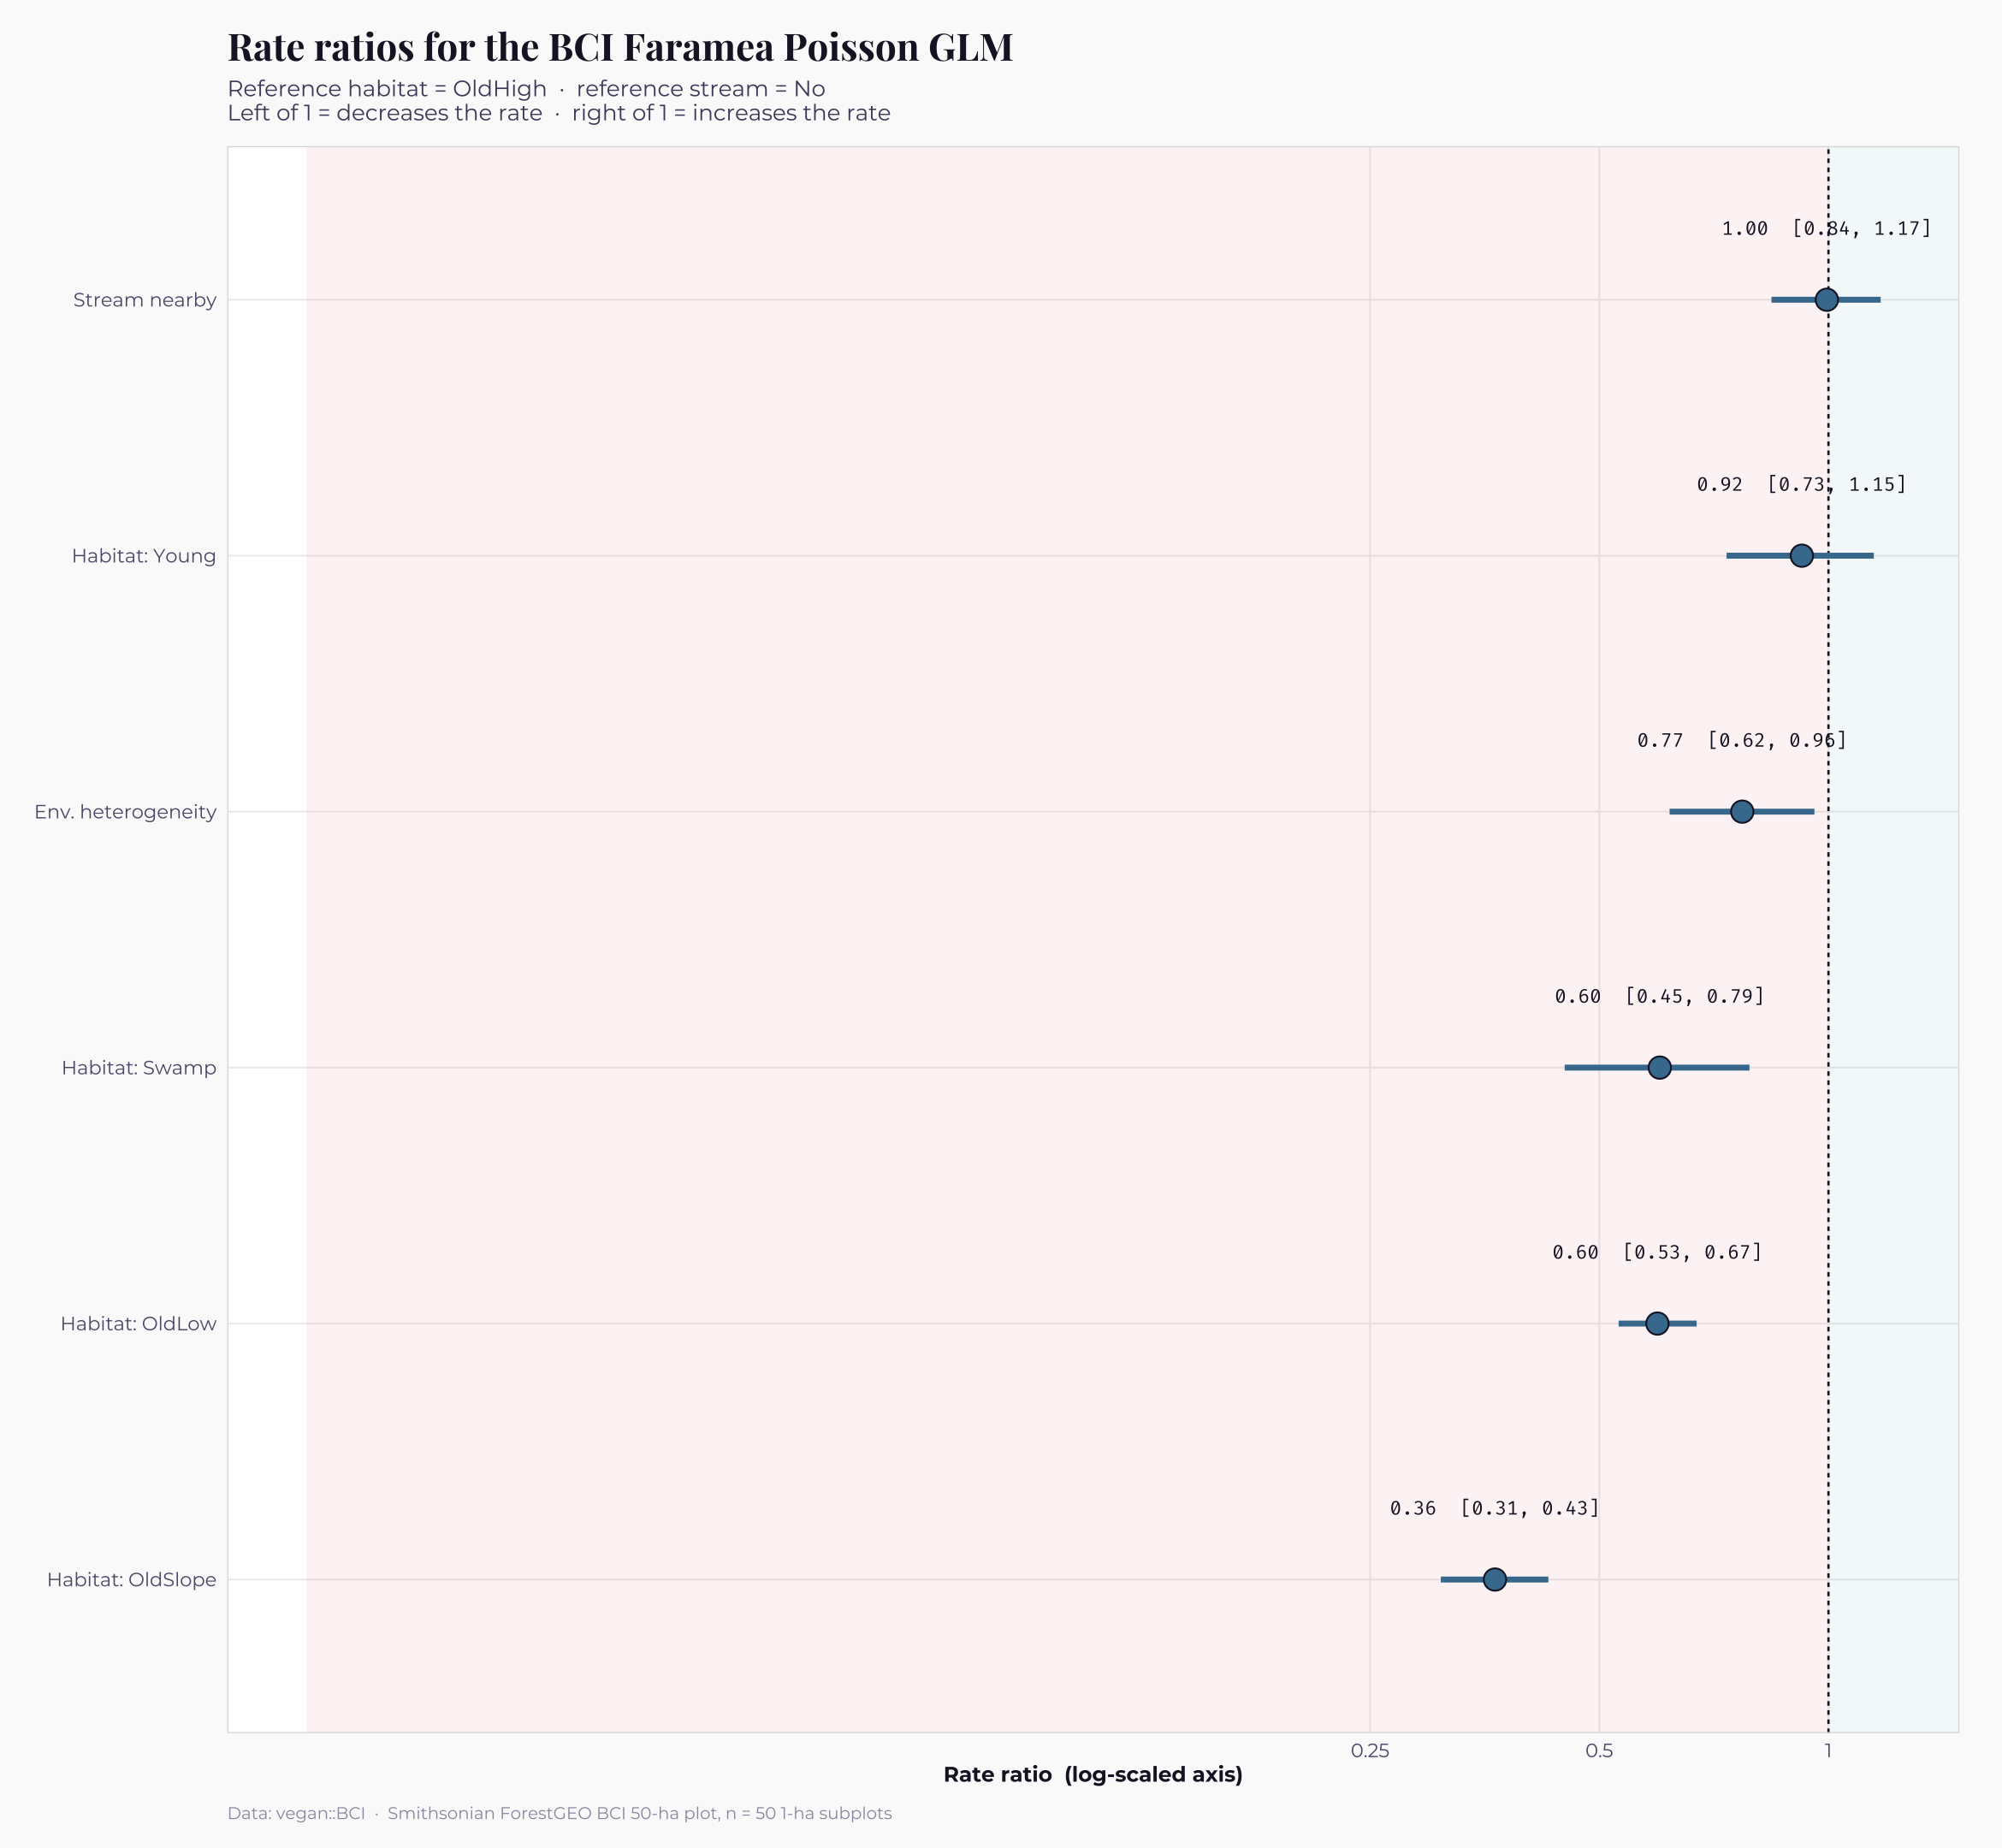

In [8]:
# A forest plot of rate ratios with CIs
library(ggplot2)

rr_plot_df <- rr_table %>%
  filter(term != "(Intercept)") %>% 
  mutate(term = recode(term,
                       "habitatOldLow"   = "Habitat: OldLow",
                       "habitatOldSlope" = "Habitat: OldSlope",
                       "habitatSwamp"    = "Habitat: Swamp",
                       "habitatYoung"    = "Habitat: Young",
                       "streamYes"       = "Stream nearby",
                       "env_het"         = "Env. heterogeneity")) %>%
  arrange(estimate)

rr_plot_df$term <- factor(rr_plot_df$term, levels = rr_plot_df$term)

ggplot(rr_plot_df, aes(x = estimate, y = term)) +
  annotate("rect", xmin = 1, xmax = Inf, ymin = -Inf, ymax = Inf,
           fill = PalDiscrete[3], alpha = 0.06) +
  annotate("rect", xmin = 0.01, xmax = 1, ymin = -Inf, ymax = Inf,
           fill = PalDiscrete[1], alpha = 0.06) +
  geom_vline(xintercept = 1, colour = "#1a1a2e", linetype = "22",
             linewidth = 0.5) +
  geom_pointrange(aes(xmin = conf.low, xmax = conf.high),
                  colour = PalDiscrete[2], linewidth = 1.3,
                  size = 0.9, fatten = 4) +
  geom_point(shape = 21, fill = PalDiscrete[2], colour = "#1a1a2e",
             size = 4.5, stroke = 0.6) +
  geom_text(aes(label = sprintf("%.2f  [%.2f, %.2f]",
                                estimate, conf.low, conf.high)),
            family = "fira", size = 3.2, colour = "#1a1a2e",
            nudge_y = 0.28) +
  scale_x_log10(breaks = c(0.25, 0.5, 1, 2),
                labels = c("0.25", "0.5", "1", "2")) +
  labs(title    = "Rate ratios for the BCI Faramea Poisson GLM",
       subtitle = "Reference habitat = OldHigh  ·  reference stream = No\nLeft of 1 = decreases the rate  ·  right of 1 = increases the rate",
       x = "Rate ratio  (log-scaled axis)",
       y = NULL,
       caption = "Data: vegan::BCI  ·  Smithsonian ForestGEO BCI 50-ha plot, n = 50 1-ha subplots") +
  theme_ml()

---
## Predicted abundance across habitats

Rate ratios are essential for communication, but the best way to check that the model is saying something sensible is to plot predictions across the predictor space. For a categorical predictor like habitat, that means producing a predicted-count interval for each level. For our continuous predictor `env_het`, it means showing how the predicted count changes across its observed range while holding habitat fixed at its most common level.

Because the log link makes the model multiplicative on the response scale, the predicted curve as a function of `env_het` is an **exponential** rather than a straight line.

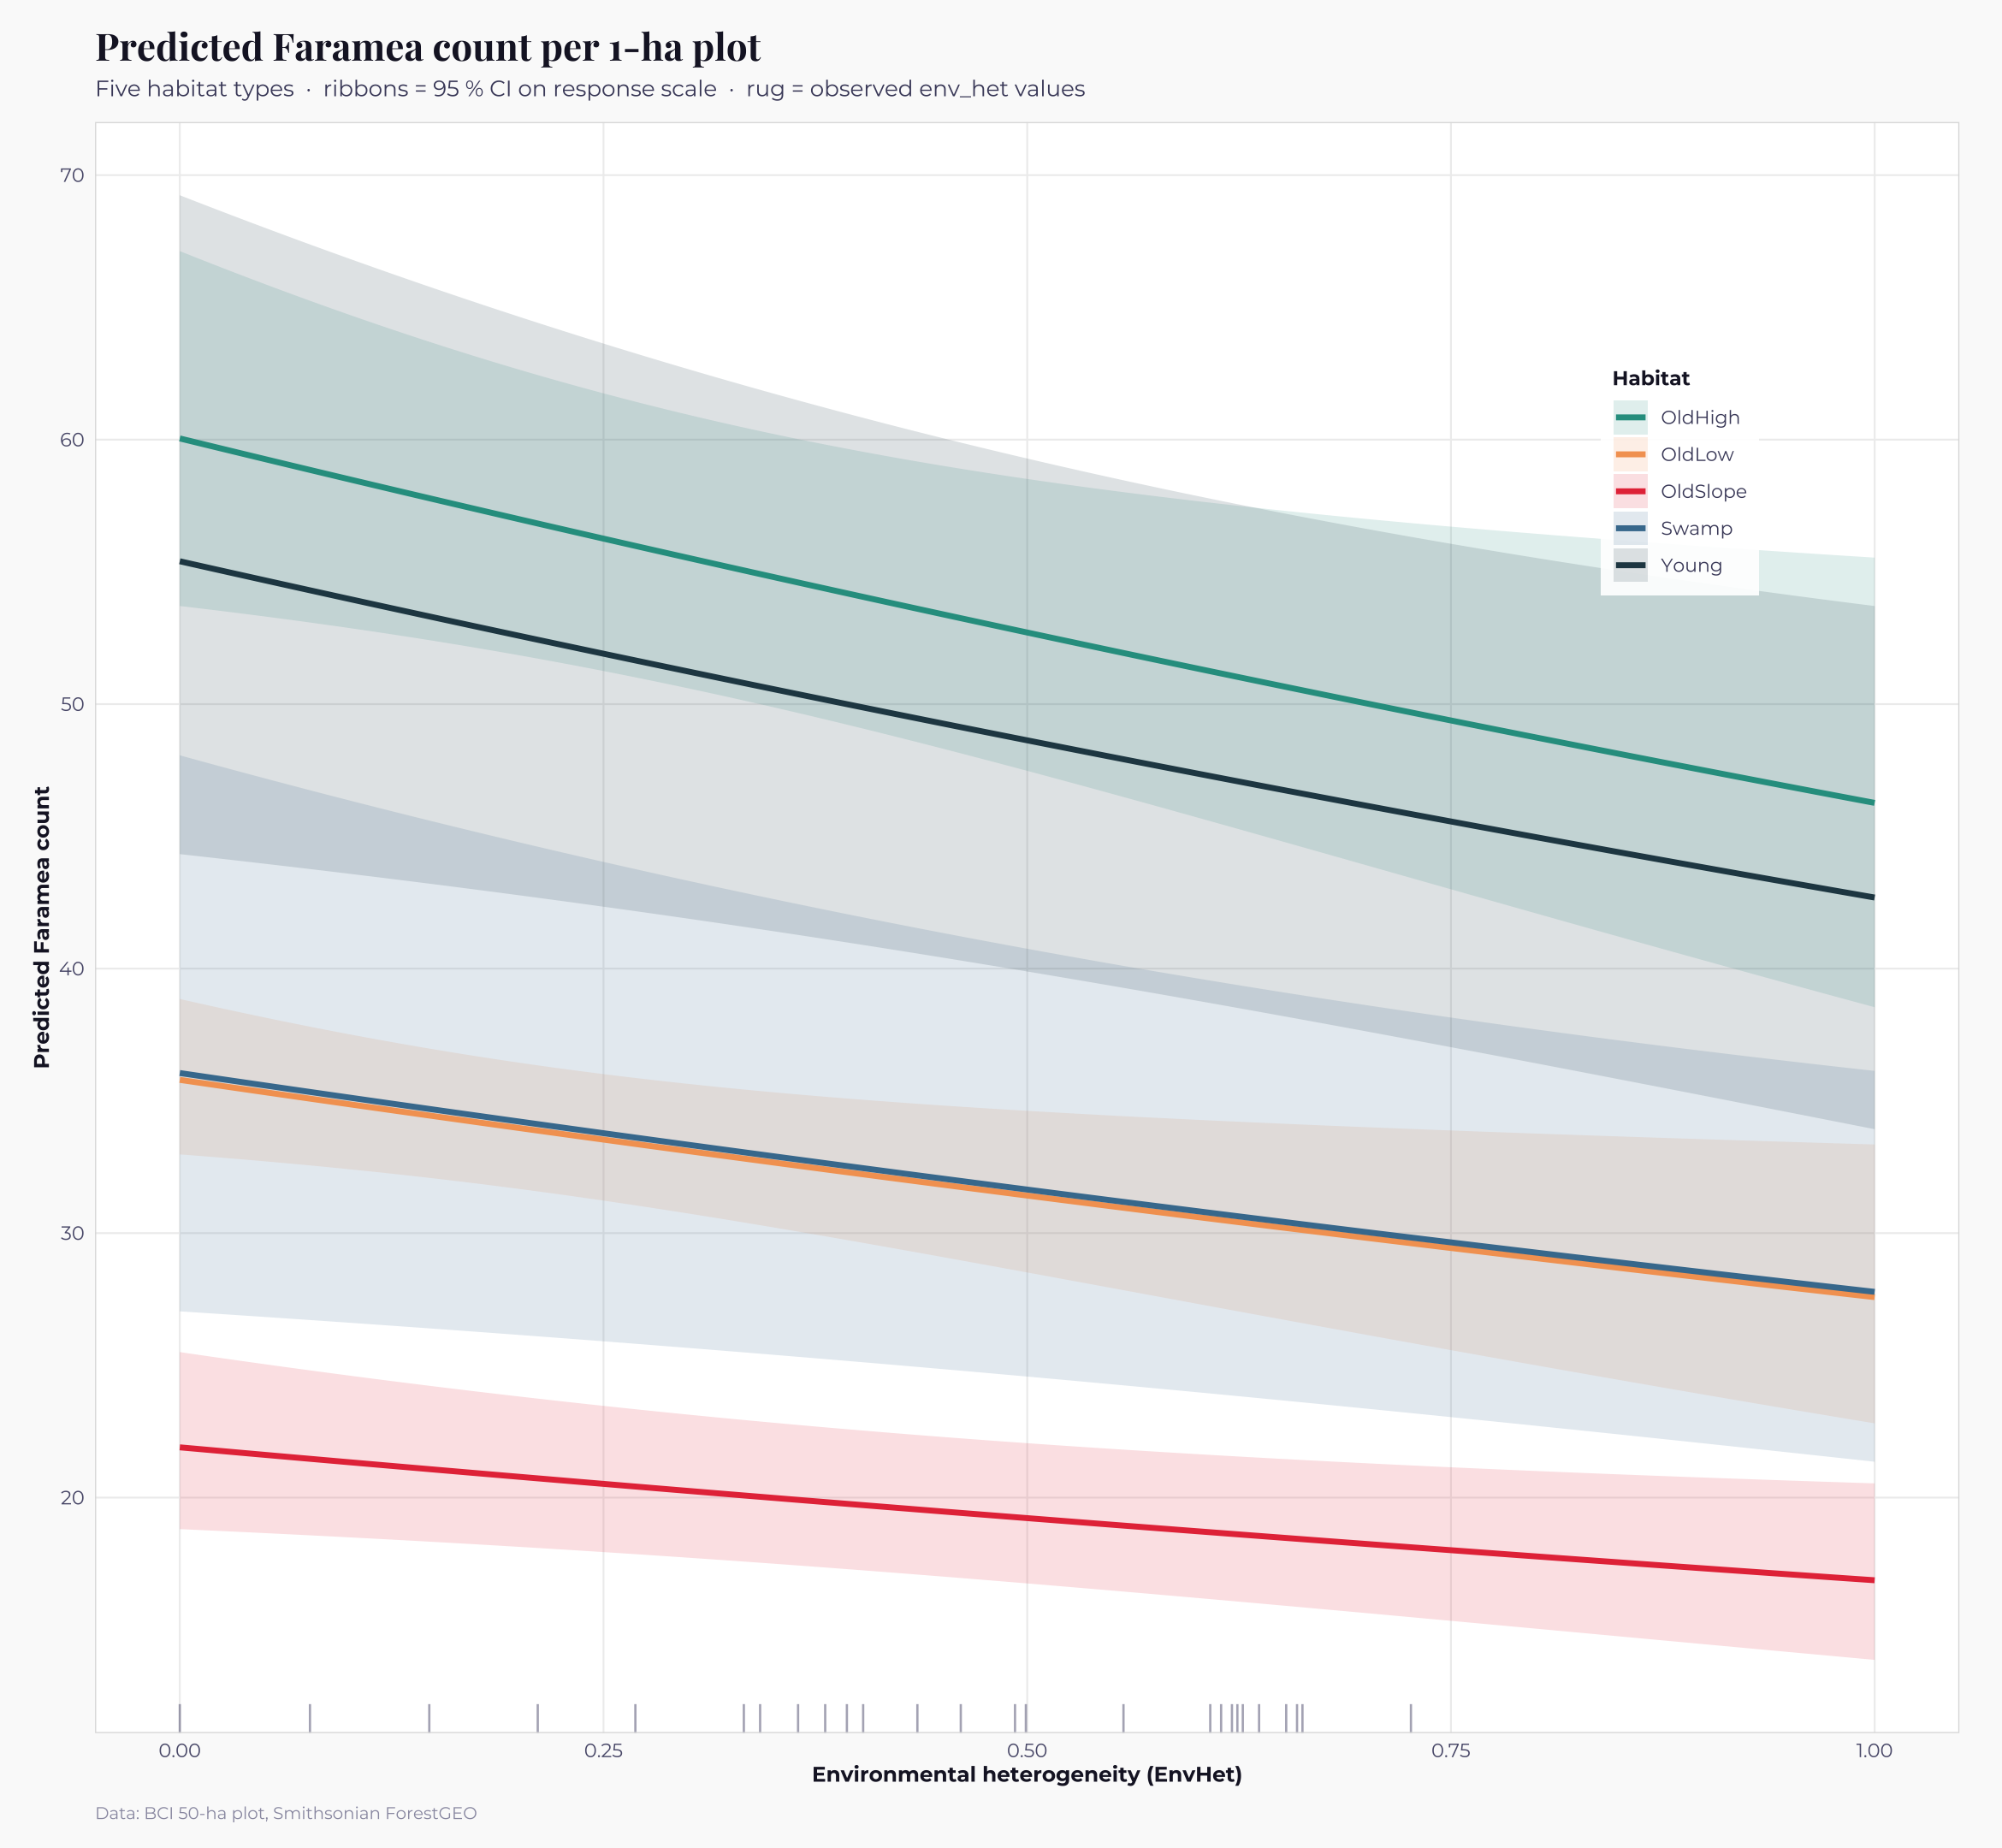

In [9]:
# Predicted Faramea count across the env_het gradient,
# for each of the five habitat types
library(ggplot2); library(tidyverse)

grid <- expand_grid(
  env_het  = seq(0, 1, length.out = 200),
  habitat  = levels(faramea$habitat),
  stream   = "No"
)

pr <- predict(fit_pois, newdata = grid, type = "link", se.fit = TRUE)
grid$fit  <- exp(pr$fit)
grid$lo   <- exp(pr$fit - 1.96 * pr$se.fit)
grid$hi   <- exp(pr$fit + 1.96 * pr$se.fit)

ggplot(grid, aes(env_het, fit, colour = habitat, fill = habitat)) +
  geom_ribbon(aes(ymin = lo, ymax = hi), alpha = 0.15, colour = NA) +
  geom_line(linewidth = 1.3) +
  geom_rug(data = faramea,
           aes(x = env_het),
           inherit.aes = FALSE,
           colour = "#5a5a7a", alpha = 0.5,
           length = unit(0.018, "npc")) +
  scale_colour_manual(values = PalDiscrete[c(3, 5, 1, 2, 7)],
                      name = "Habitat") +
  scale_fill_manual  (values = PalDiscrete[c(3, 5, 1, 2, 7)],
                      name = "Habitat") +
  labs(title    = "Predicted Faramea count per 1-ha plot",
       subtitle = "Five habitat types  ·  ribbons = 95 % CI on response scale  ·  rug = observed env_het values",
       x = "Environmental heterogeneity (EnvHet)",
       y = "Predicted Faramea count",
       caption = "Data: BCI 50-ha plot, Smithsonian ForestGEO") +
  theme_ml() +
  theme(legend.position = c(0.85, 0.78),
        legend.background = element_rect(fill = alpha("white", 0.9),
                                          colour = NA))


Two features of this figure are worth dwelling on. First, the curves are **exponential** in `env_het` — a fixed *additive* change in heterogeneity produces a fixed *multiplicative* change in the predicted *Faramea* count. The log link makes every effect multiplicative on the response scale; a unit change in `env_het` shifts the predicted count by the factor $\exp(\hat\beta_{\text{EnvHet}})$ regardless of which habitat or starting value we started at.

Second, the confidence ribbons **widen** at the extremes of the heterogeneity gradient. This is because, on the log scale, the variance of the linear predictor is smallest near the centre of the data and grows toward the edges — exactly as it did for linear regression. Exponentiating back to the response scale amplifies this pattern dramatically, because small uncertainty in the log of a small number blows up into large uncertainty in a large number. If you intend to extrapolate a Poisson GLM far beyond your observed range, the confidence ribbon is the first thing you should look at, not the point estimate.

Third — and this is something a sharp-eyed reader will spot from the figure — the difference in predicted abundance between `OldHigh` and `OldSlope` is larger than the difference between `OldLow` and `Swamp`. *Faramea* is fundamentally a tree of well-drained terrain. Old-growth forest on flat moist ground or in seasonal swamps offers it less than half the carrying capacity of old-growth forest on the higher ridges. This is the kind of ecological insight a Poisson GLM was made to deliver.


---
## Overdispersion — the quiet killer of ecological counts

The Poisson distribution has a striking and inconvenient property: its variance equals its mean exactly. If the expected count is three, its variance is three. If the expected count is three hundred, its variance is three hundred. For any real ecological count data you are likely to meet, this is optimistic to the point of delusion. Birds cluster because they are territorial or because they flock. Plants cluster because they disperse their seeds only a few metres. Parasites cluster because their hosts aggregate. The upshot is **overdispersion** — the variance of real counts is usually larger than the mean, sometimes by a factor of ten or more.

Overdispersion rarely biases the Poisson point estimates — the $\hat\beta$'s remain approximately unbiased. What it ruins is the **standard errors**, which are derived under the assumption that the variance equals the mean. When the true variance is larger, the standard errors are too small, the confidence intervals are too narrow, and the p-values are too enthusiastic. This is a quiet failure mode: the fitted line looks fine on a plot, but every statement of significance is overconfident, and the resulting paper will make bolder claims than the data can actually support.

A quick diagnostic: compute the ratio of the residual deviance to its degrees of freedom. Under a well-specified Poisson model this ratio should be close to 1. A ratio of 2 suggests mild overdispersion; a ratio of 5 or more suggests a serious problem. R will compute this for you in a single line.

In [11]:
# Dispersion check for the BCI Faramea Poisson fit
disp_ratio <- deviance(fit_pois) / df.residual(fit_pois)
cat(sprintf("Residual deviance : %.2f on %d df\n",
            deviance(fit_pois), df.residual(fit_pois)))
cat(sprintf("Dispersion ratio  : %.2f\n", disp_ratio))

if (disp_ratio > 1.5) {
  cat("\n Overdispersion detected — Poisson SEs are too narrow.\n")
} else {
  cat("\n No clear overdispersion.\n")
}

Residual deviance : 176.85 on 43 df
Dispersion ratio  : 4.11

 Overdispersion detected — Poisson SEs are too narrow.



The BCI Faramea data come back with a dispersion ratio of around 4 — a textbook example of overdispersion. This is exactly what we should expect from a clumped tropical tree species: *Faramea* recruits in cohorts when light gaps open, propagates short distances by primate dispersal, and clusters spatially around adult trees. None of this clustering is captured by a Poisson model that assumes counts are independent draws from a distribution where variance equals mean.

The fix is the **negative binomial** distribution, which generalises the Poisson by introducing one extra parameter — usually called $\theta$ or the *dispersion parameter* — that allows the variance to grow as a quadratic function of the mean:

$$
\text{Var}(y) \;=\; \mu + \frac{\mu^2}{\theta}.
$$

When $\theta \to \infty$, the negative binomial collapses back to the Poisson. When $\theta$ is small (e.g. 1 or less), the variance can be many times the mean. We refit the same Faramea model under a negative binomial assumption and compare.


In [12]:
# Refit the BCI Faramea model under a negative-binomial assumption
library(MASS)

fit_nb <- MASS::glm.nb(
  count ~ habitat + stream + env_het,
  data = faramea
)

cat(sprintf("Poisson dispersion ratio : %.2f  (far above 1 → overdispersion)\n",
            disp_ratio))
cat(sprintf("NB theta estimate        : %.2f  (CI [%.2f, %.2f])\n",
            fit_nb$theta, fit_nb$theta - 1.96 * fit_nb$SE.theta,
            fit_nb$theta + 1.96 * fit_nb$SE.theta))
cat(sprintf("\nAIC Poisson : %.1f\n", AIC(fit_pois)))
cat(sprintf("AIC NB      : %.1f  (lower is better)\n", AIC(fit_nb)))

Poisson dispersion ratio : 4.11  (far above 1 → overdispersion)
NB theta estimate        : 12.39  (CI [5.43, 19.36])

AIC Poisson : 453.8
AIC NB      : 395.1  (lower is better)



The negative binomial fits dramatically better than the Poisson — the AIC drops by tens of points, which is overwhelming evidence in favour of the NB model. The estimated $\theta$ around 12 is well-defined (the CI does not include very large values, which would indicate the Poisson is adequate). What changes for the coefficients?


Warning message in annotate("label", x = ann_x, y = ann_y_top, hjust = 0, vjust = 1, :
“Ignoring unknown parameters: `label.size`”
Warning message in annotate("label", x = ann_x, y = ann_y_mid, hjust = 0, vjust = 1, :
“Ignoring unknown parameters: `label.size`”


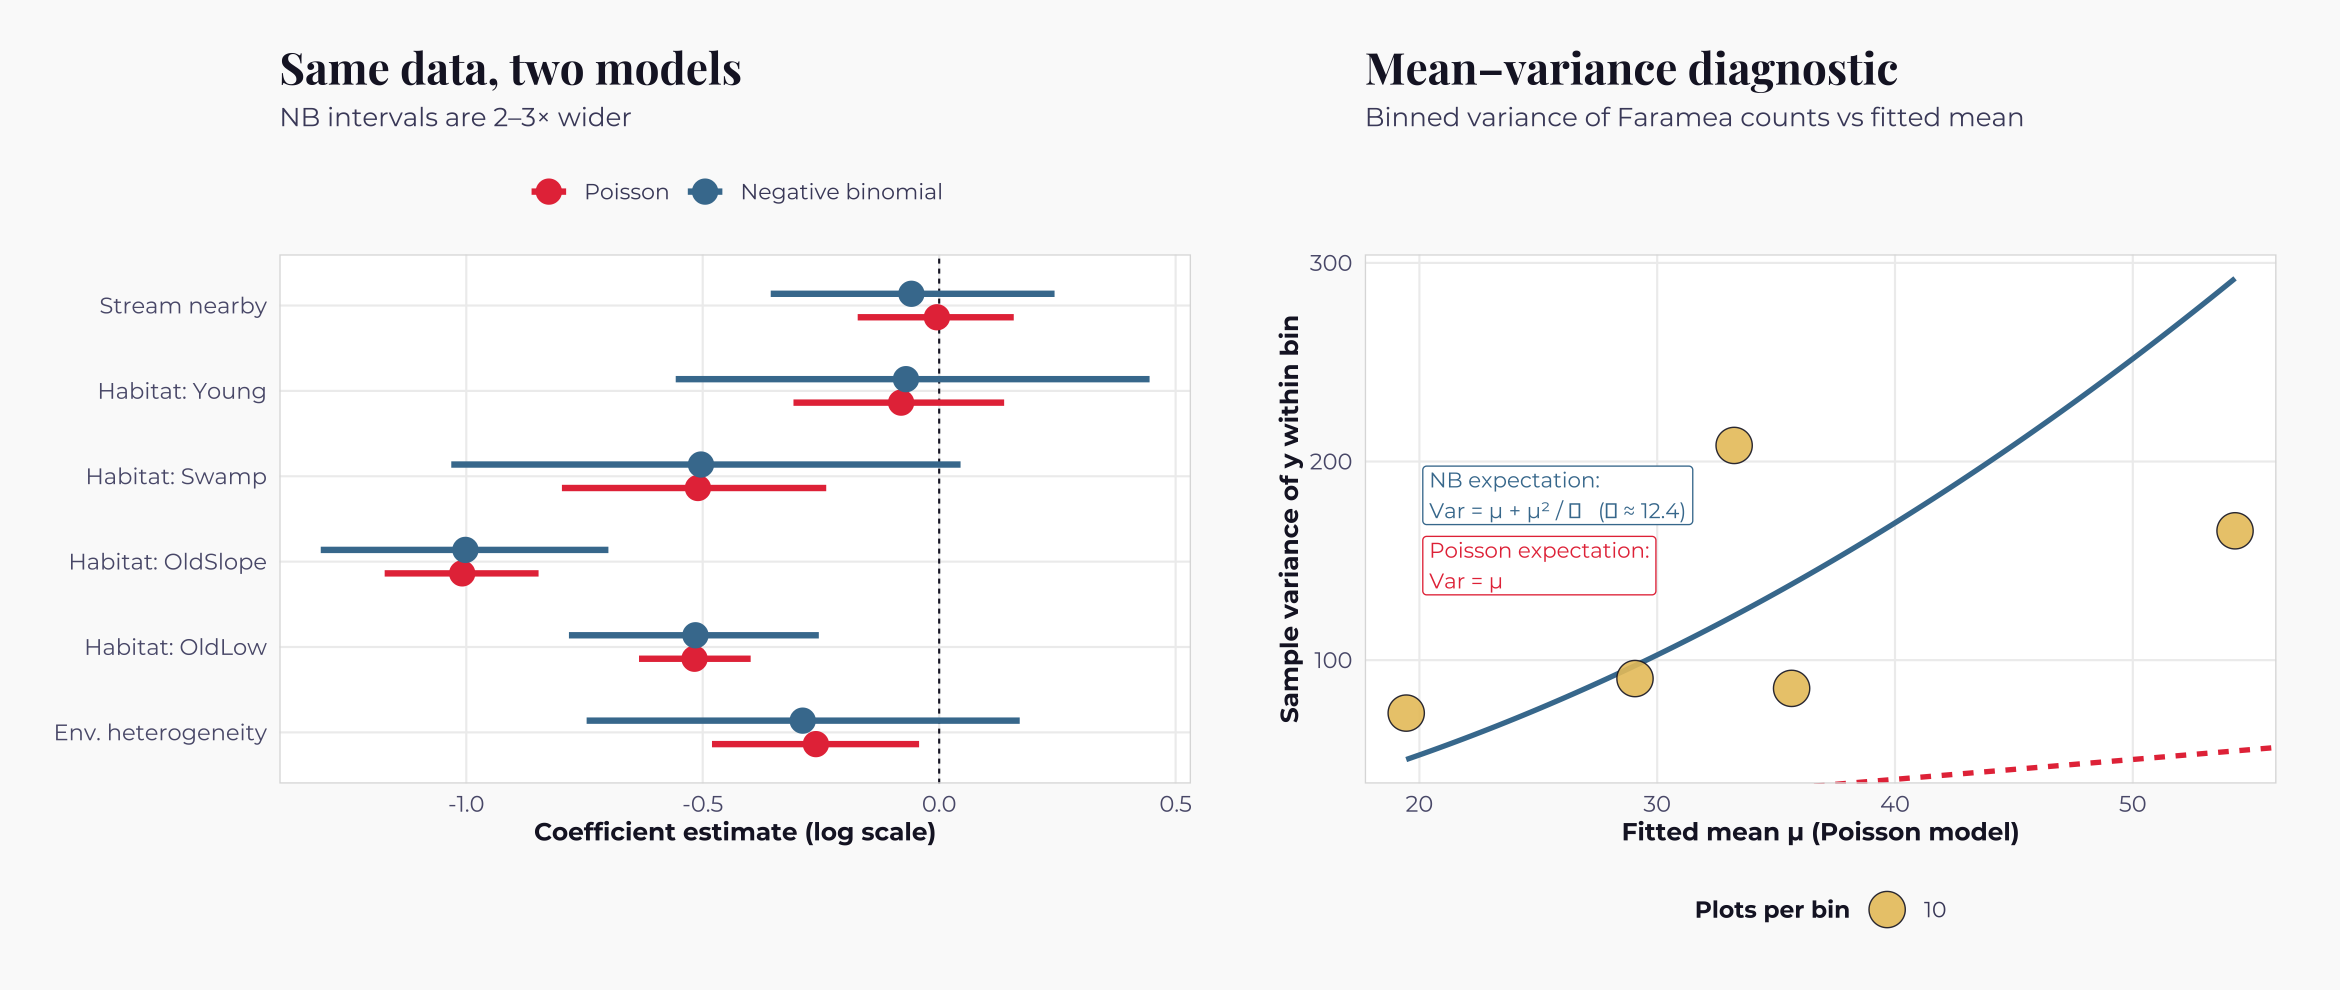

In [13]:
# Compare coefficient estimates and their confidence intervals
library(tidyverse); library(patchwork); library(broom)

compare_coefs <- bind_rows(
  broom::tidy(fit_pois, conf.int = TRUE) %>% mutate(model = "Poisson"),
  broom::tidy(fit_nb,   conf.int = TRUE) %>% mutate(model = "Negative binomial")
) %>%
  filter(term != "(Intercept)") %>%
  mutate(term = recode(term,
                       "habitatOldLow"   = "Habitat: OldLow",
                       "habitatOldSlope" = "Habitat: OldSlope",
                       "habitatSwamp"    = "Habitat: Swamp",
                       "habitatYoung"    = "Habitat: Young",
                       "streamYes"       = "Stream nearby",
                       "env_het"         = "Env. heterogeneity"),
         model = factor(model, levels = c("Poisson", "Negative binomial")))

# Panel A — coefficient comparison
P_coef <- ggplot(compare_coefs,
                 aes(x = estimate, y = term, colour = model)) +
  geom_vline(xintercept = 0, colour = "#1a1a2e", linetype = "22",
             linewidth = 0.4) +
  geom_pointrange(aes(xmin = conf.low, xmax = conf.high),
                  position = position_dodge(0.55),
                  linewidth = 1.2, size = 0.9, fatten = 4) +
  scale_colour_manual(values = c("Poisson"           = PalDiscrete[1],
                                 "Negative binomial" = PalDiscrete[2]),
                      name = NULL) +
  labs(title    = "Same data, two models",
       subtitle = "NB intervals are 2–3× wider",
       x = "Coefficient estimate (log scale)",
       y = NULL) +
  theme_ml() +
  theme(legend.position = "top")

# Panel B — mean–variance relationship in the data
binned <- tibble(
  mu = fitted(fit_pois),
  y  = faramea$count
) %>%
  mutate(mu_bin = cut(mu, quantile(mu, seq(0, 1, 0.2)),
                      include.lowest = TRUE)) %>%
  group_by(mu_bin) %>%
  summarise(mu_mid = mean(mu), var_y = var(y), n = n(), .groups = "drop")

mu_seq <- seq(min(binned$mu_mid), max(binned$mu_mid), length.out = 100)
theta_hat <- fit_nb$theta

ann_x <- min(binned$mu_mid) + 0.02 * diff(range(binned$mu_mid))
ann_y_top <- max(binned$var_y) * 0.95
ann_y_mid <- max(binned$var_y) * 0.78

P_mv <- ggplot(binned, aes(mu_mid, var_y)) +
  geom_abline(slope = 1, intercept = 0,
              colour = PalDiscrete[1], linewidth = 1, linetype = "22") +
  geom_line(data = tibble(mu_mid = mu_seq,
                          var_y  = mu_seq + mu_seq^2 / theta_hat),
            colour = PalDiscrete[2], linewidth = 1) +
  geom_point(aes(size = n), shape = 21, fill = PalDiscrete[4],
             colour = "#1a1a2e", stroke = 0.4, alpha = 0.9) +
  scale_size_continuous(range = c(3, 8), name = "Plots per bin") +
  annotate("label", x = ann_x, y = ann_y_top, hjust = 0, vjust = 1,
           label = sprintf("NB expectation:\nVar = μ + μ² / θ   (θ ≈ %.1f)",
                           theta_hat),
           family = "mont", size = 3.0, colour = PalDiscrete[2],
           fill = "#ffffff", label.size = 0.2) +
  annotate("label", x = ann_x, y = ann_y_mid, hjust = 0, vjust = 1,
           label = "Poisson expectation:\nVar = μ",
           family = "mont", size = 3.0, colour = PalDiscrete[1],
           fill = "#ffffff", label.size = 0.2) +
  labs(title    = "Mean–variance diagnostic",
       subtitle = "Binned variance of Faramea counts vs fitted mean",
       x = "Fitted mean μ (Poisson model)",
       y = "Sample variance of y within bin") +
  theme_ml()

options(repr.plot.width = 13, repr.plot.height = 5.5)
(P_coef | P_mv) +
  plot_annotation(
    theme = theme(plot.background = element_rect(fill = "#fafafa", colour = NA)))

The right-hand panel is worth studying carefully. The dashed red line is the Poisson prediction that the variance equals the mean — a straight diagonal. The solid blue curve is the negative-binomial prediction that the variance grows quadratically. The dots are the actual sample variances of the observed counts, binned by their fitted means. The data sit clearly on the blue curve and clearly above the red line, which is exactly the signature of overdispersion. Any ecologist who fits a Poisson to count data should produce something like this figure as a routine diagnostic. Dispersion ratios summarise the problem in a single number; mean-variance plots show you its shape.

### Alternatives at a glance

The negative binomial is the standard first-line response to overdispersion but it is not the only option. Three alternatives are worth knowing the names of.

**Quasi-Poisson** is the lazy statistician's fix. It keeps the Poisson point estimates but inflates the standard errors by a factor of $\sqrt{\hat\phi}$, where $\hat\phi$ is the empirical dispersion ratio. It requires a single extra parameter and works well when overdispersion is the only problem, but it is not a proper likelihood and so it cannot be compared to other models using AIC or likelihood-ratio tests. Use it when you need a quick fix; use the negative binomial when you want a model you can stand behind.

**Zero-inflated Poisson or negative binomial** models handle a special form of overdispersion where the data contain far more zeros than any Poisson-ish distribution can explain. The idea is a mixture: one process decides whether an observation is a "structural zero" (the species is simply not present), and a second process generates a count (including the occasional zero) when the species is present. These models are popular in occupancy-style studies but add interpretive complexity.

**The Tweedie family** handles continuous data with a spike at exactly zero — biomass of a species that is absent from many plots, catch-per-unit-effort in fisheries, rainfall totals. It is a one-parameter family that smoothly bridges the gamma and the Poisson.

---
## Gamma regression for positive continuous data

We turn now from counts to a different kind of response: biomass. Tree biomass is strictly positive, right-skewed, and displays variance that grows with the mean — the classic signature of data well-described by a **gamma distribution**. A gamma GLM with a log link is the principled way to model such responses.

There is a traditional ecological reflex of log-transforming biomass and fitting `lm(log(biomass) ~ ...)`. This is sometimes adequate but has two well-known problems. First, the coefficients describe the mean of $\log(y)$, not the log of the mean of $y$ — a distinction that becomes awkward when you want to back-transform predictions to the response scale, where a correction factor (Sprugel 1983) is needed to avoid bias. Second, you cannot log-transform zeros, which forces you to add an arbitrary constant to the data. A gamma GLM with a log link avoids both problems: it models $\log(\mathbb{E}[y])$ directly and it can in principle handle any strictly positive response without transformation.

Our example uses one of the most-loved datasets in R: **`datasets::trees`**, which records the volume (cubic feet), girth at breast height (inches), and height (feet) of 31 felled black cherry (*Prunus serotina*) trees from the Allegheny National Forest in Pennsylvania. The dataset was first reported in Ryan, Joiner and Ryan's *Minitab Handbook* (1976) and has been a teaching workhorse ever since. Note that "girth" here means **circumference**, not diameter — to convert to DBH you divide by π — but for our purposes the units do not matter because we will use $\log(\text{Girth})$ and the offset will go into the intercept.

The basic geometric expectation is illuminating. If a tree trunk were a perfect cylinder, its volume would be $V = \pi r^2 h$, where $r$ is the radius and $h$ the height. Since girth scales linearly with diameter, we expect $V \propto \text{Girth}^2 \times \text{Height}$, or equivalently:

$$
\log V \;=\; \beta_0 \;+\; 2 \cdot \log(\text{Girth}) \;+\; 1 \cdot \log(\text{Height}).
$$

A real tree, of course, is not a cylinder — it tapers — so the empirical exponents may deviate from these clean integers. The gamma GLM is the right tool to find out.

In [16]:
# Load the datasets::trees data
data(trees)
trees_df <- as_tibble(trees)
cat("Black cherry trees:", nrow(trees_df), "  ·  variables:",
    paste(names(trees_df), collapse = ", "), "\n")
cat("\nFirst six trees:\n")

Black cherry trees: 31   ·  variables: Girth, Height, Volume 

First six trees:


In [17]:
print(head(trees_df))

# A tibble: 6 × 3
  Girth Height Volume
  <dbl>  <dbl>  <dbl>
1   8.3     70   10.3
2   8.6     65   10.3
3   8.8     63   10.2
4  10.5     72   16.4
5  10.7     81   18.8
6  10.8     83   19.7


In [18]:
cat("\nRanges:\n")
cat("  Girth (inches):", paste(range(trees_df$Girth),  collapse = "–"), "\n")
cat("  Height (feet) :", paste(range(trees_df$Height), collapse = "–"), "\n")
cat("  Volume (ft³)  :", paste(range(trees_df$Volume), collapse = "–"), "\n")


Ranges:
  Girth (inches): 8.3–20.6 
  Height (feet) : 63–87 
  Volume (ft³)  : 10.2–77 


In [19]:
# Gamma GLM with log link — the geometric prior is V ∝ Girth² × Height
fit_gamma <- glm(
  Volume ~ log(Girth) + log(Height),
  family = Gamma(link = "log"),
  data   = trees_df
)
summary(fit_gamma)


Call:
glm(formula = Volume ~ log(Girth) + log(Height), family = Gamma(link = "log"), 
    data = trees_df)

Coefficients:
            Estimate Std. Error t value Pr(>|t|)    
(Intercept) -6.69111    0.78784  -8.493 3.11e-09 ***
log(Girth)   1.98041    0.07389  26.802  < 2e-16 ***
log(Height)  1.13288    0.20138   5.625 5.04e-06 ***
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1

(Dispersion parameter for Gamma family taken to be 0.006427286)

    Null deviance: 8.31720  on 30  degrees of freedom
Residual deviance: 0.18352  on 28  degrees of freedom
AIC: 139.9

Number of Fisher Scoring iterations: 3



The fitted exponents come back at 1.98 for $\log(\text{Girth})$ and 1.13 for $\log(\text{Height})$ — strikingly close to the geometric expectation of $2.0$ and $1.0$ for a cylindrical trunk. The small departures are biologically interpretable. The Girth exponent of 1.98 is essentially indistinguishable from 2.0; black cherry trunks scale very nearly as cylinders in their cross-section. The Height exponent of 1.13 is slightly above 1.0, suggesting that tall trees are *not quite* simple cylinders — they tend also to be slightly fatter at the base than short trees, so volume grows a little faster than height alone. The residual deviance (0.18 on 28 df) is tiny relative to the null deviance (8.32 on 30 df), and the dispersion parameter is about 0.006, implying a coefficient of variation in volume of around 8 % at any given size. This is a remarkably tight allometric fit — real ecological data behaving almost like physics.

The figure below plots observed volume against girth on log-log axes and overlays the fitted gamma curve for three height scenarios.


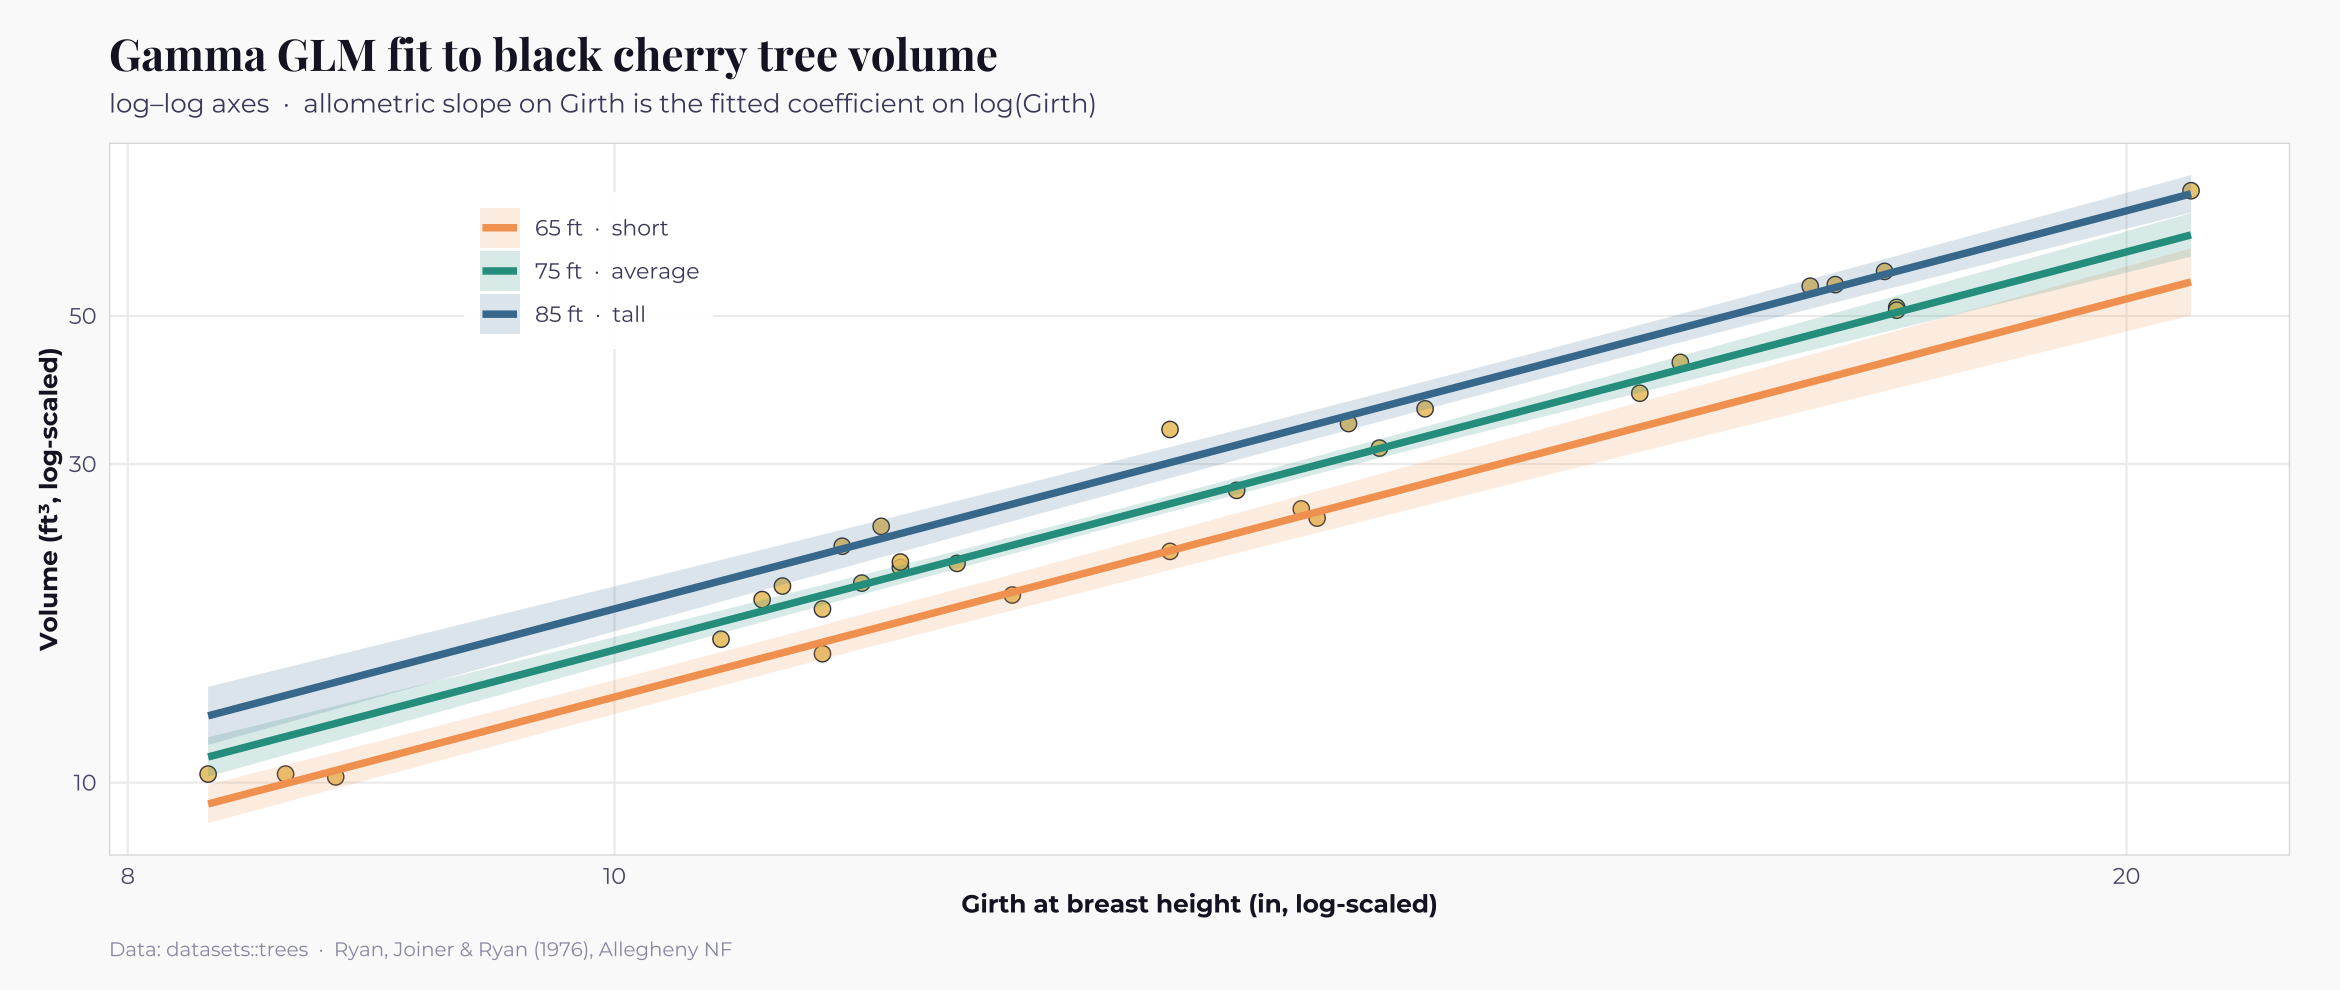

In [20]:
# Fitted curves from the gamma GLM, for three height scenarios
library(ggplot2); library(tidyverse)

grid_t <- expand_grid(
  Girth  = seq(min(trees_df$Girth), max(trees_df$Girth), length.out = 200),
  Height = c(65, 75, 85)
)
pr_t <- predict(fit_gamma, newdata = grid_t, type = "link", se.fit = TRUE)
grid_t$fit <- exp(pr_t$fit)
grid_t$lo  <- exp(pr_t$fit - 1.96 * pr_t$se.fit)
grid_t$hi  <- exp(pr_t$fit + 1.96 * pr_t$se.fit)
grid_t$h_lab <- factor(grid_t$Height,
                       labels = c("65 ft  ·  short",
                                  "75 ft  ·  average",
                                  "85 ft  ·  tall"))

ggplot() +
  geom_point(data = trees_df, aes(Girth, Volume),
             shape = 21, fill = PalDiscrete[4], colour = "#1a1a2e",
             size = 2.8, stroke = 0.4, alpha = 0.85) +
  geom_ribbon(data = grid_t,
              aes(x = Girth, ymin = lo, ymax = hi, fill = h_lab),
              alpha = 0.18, colour = NA) +
  geom_line(data = grid_t,
            aes(x = Girth, y = fit, colour = h_lab),
            linewidth = 1.4) +
  scale_x_log10() +
  scale_y_log10(labels = label_comma()) +
  scale_colour_manual(values = c(PalDiscrete[5], PalDiscrete[3], PalDiscrete[2]),
                      name = NULL) +
  scale_fill_manual  (values = c(PalDiscrete[5], PalDiscrete[3], PalDiscrete[2]),
                      name = NULL) +
  labs(title    = "Gamma GLM fit to black cherry tree volume",
       subtitle = "log–log axes  ·  allometric slope on Girth is the fitted coefficient on log(Girth)",
       x = "Girth at breast height (in, log-scaled)",
       y = "Volume (ft³, log-scaled)",
       caption = "Data: datasets::trees  ·  Ryan, Joiner & Ryan (1976), Allegheny NF") +
  theme_ml() +
  theme(legend.position = c(0.22, 0.82),
        legend.background = element_rect(fill = alpha("white", 0.9),
                                          colour = NA))


On log-log axes the gamma fits come out as perfectly straight lines — because the model is $\log(\mathbb{E}[y]) = \beta_0 + 2.3 \cdot \log(\text{DBH}) + 0.0008 \cdot \text{rainfall}$, and on log axes that is a straight line with slope 2.3. The three parallel lines correspond to the three rainfall levels. This kind of figure — log-log axes, a gamma GLM with $\log(\text{DBH})$ as predictor — is the workhorse plot of the entire forest-biomass literature.


---
## Comparing GLMs with AIC

Most ecological analyses involve deciding between several plausible models: is habitat quality alone enough, or do we also need forest cover? Does an interaction between them improve the fit enough to justify the extra parameter? The **Akaike Information Criterion** (AIC), introduced by Hirotogu Akaike in 1974, provides a principled way to make these comparisons. Its formula is short and its interpretation deep:

$$
\text{AIC} \;=\; -2 \ell(\hat\theta) \;+\; 2k,
$$

where $\ell(\hat\theta)$ is the maximised log-likelihood of the model and $k$ is the number of estimated parameters. The first term rewards fit to the data; the second term penalises complexity. Lower AIC is better. Differences in AIC between competing models — $\Delta\text{AIC}$ — are what matter; absolute AIC values are not meaningful on their own.

Burnham and Anderson's widely-cited rule of thumb says that a $\Delta\text{AIC}$ below 2 means the models are essentially indistinguishable; a $\Delta\text{AIC}$ between 4 and 7 indicates moderate support for the better model; and a $\Delta\text{AIC}$ above 10 means the worse model has essentially no support. These are guidelines, not hard thresholds, and they should be paired with residual diagnostics and ecological plausibility rather than used in isolation.

In [21]:
# Four candidate models for the BCI Faramea data
m1 <- glm(count ~ habitat,
          family = poisson, data = faramea)
m2 <- glm(count ~ env_het,
          family = poisson, data = faramea)
m3 <- glm(count ~ habitat + env_het,
          family = poisson, data = faramea)
m4 <- glm(count ~ habitat + env_het + stream,
          family = poisson, data = faramea)

aic_tbl <- tibble(
  model = c("habitat only",
            "EnvHet only",
            "habitat + EnvHet",
            "habitat + EnvHet + stream"),
  k     = c(length(coef(m1)), length(coef(m2)),
            length(coef(m3)), length(coef(m4))),
  AIC   = c(AIC(m1), AIC(m2), AIC(m3), AIC(m4))
) %>%
  mutate(dAIC = AIC - min(AIC),
         w    = exp(-0.5 * dAIC) / sum(exp(-0.5 * dAIC))) %>%
  arrange(AIC)

print(aic_tbl, digits = 4)

# A tibble: 4 × 5
  model                         k   AIC   dAIC        w
  <chr>                     <int> <dbl>  <dbl>    <dbl>
1 habitat + EnvHet              6  452.   0    6.65e- 1
2 habitat + EnvHet + stream     7  454.   2.00 2.45e- 1
3 habitat only                  5  456.   4.01 8.98e- 2
4 EnvHet only                   2  626. 174.   1.20e-38


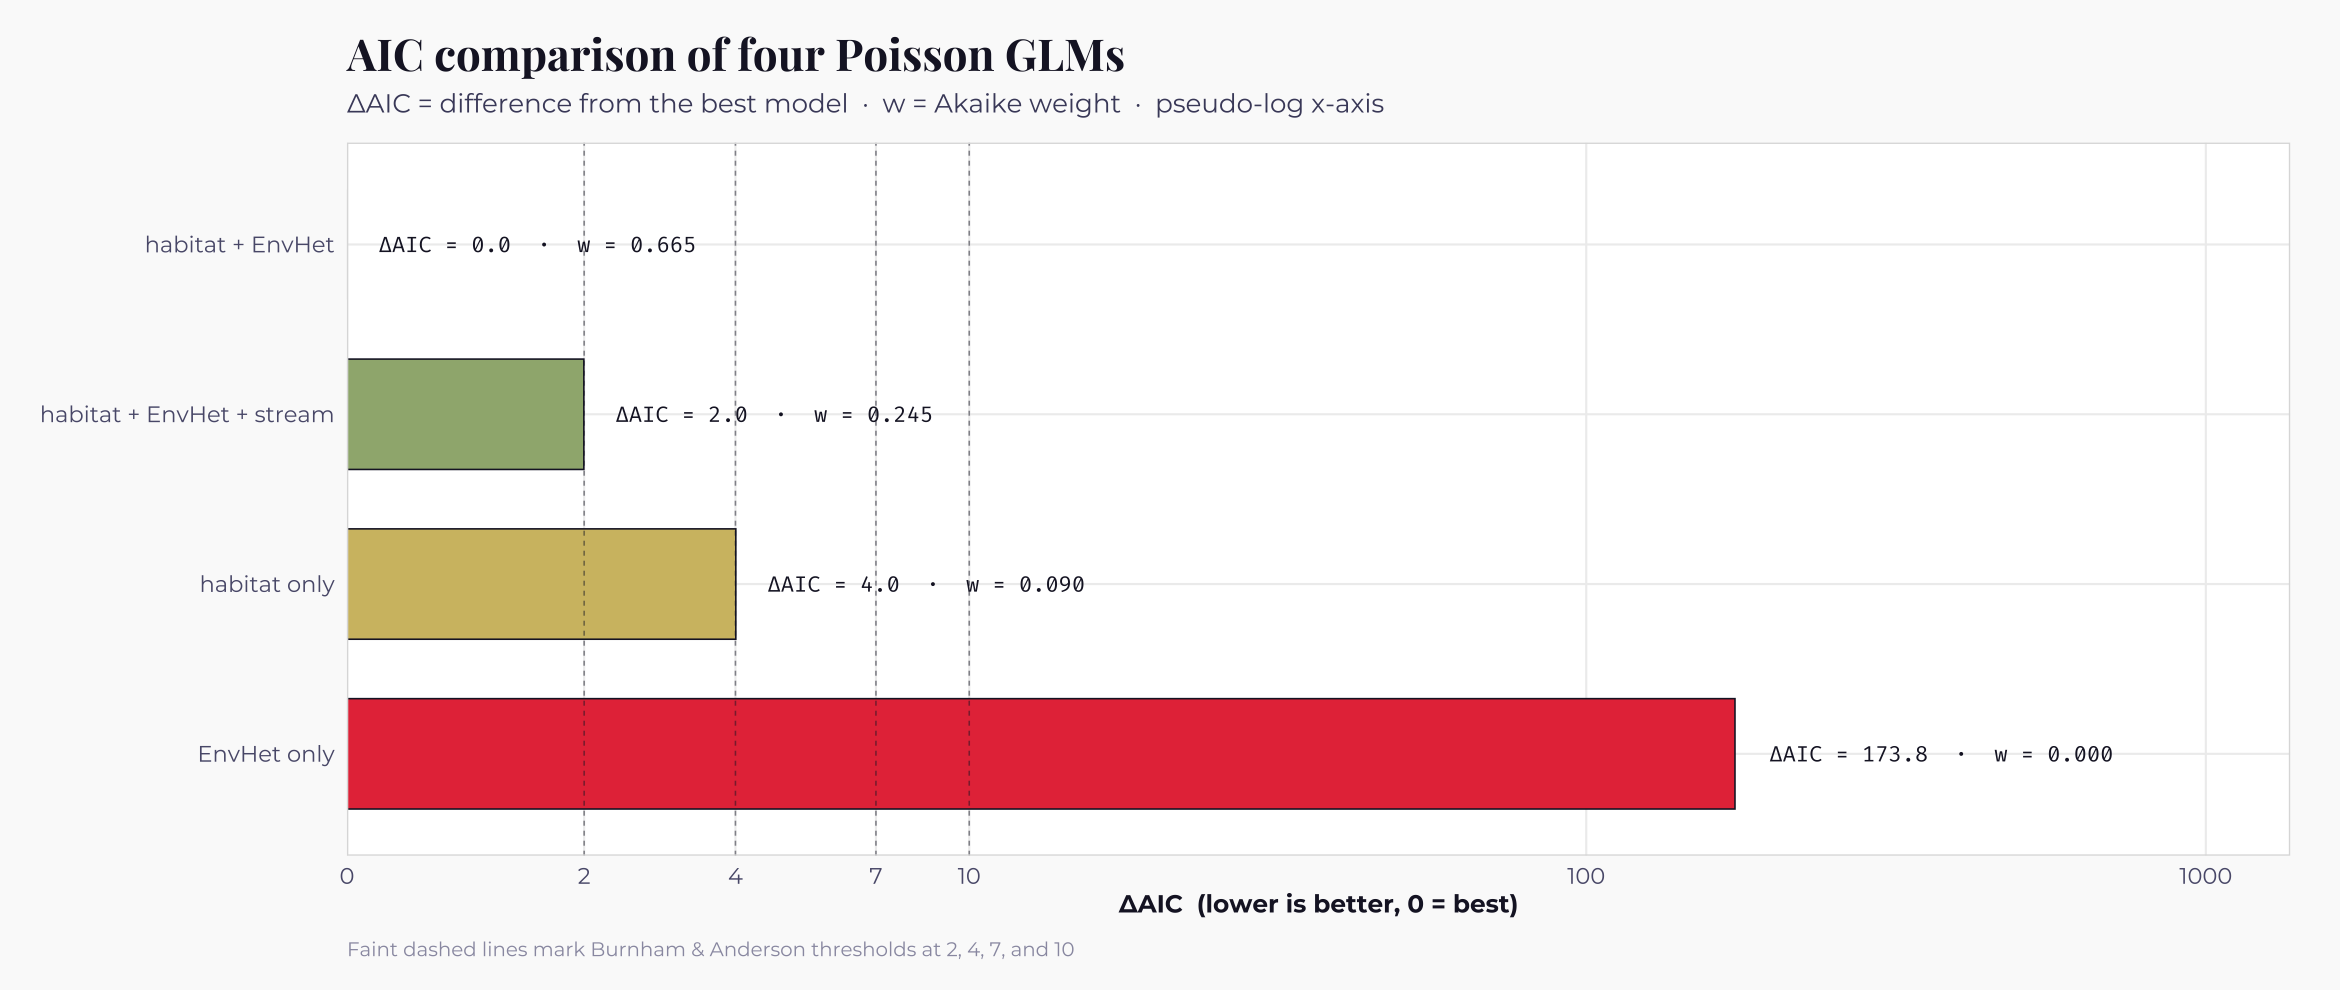

In [22]:
# A small, clean AIC comparison plot
library(ggplot2)

aic_plot_df <- aic_tbl %>%
  mutate(model = factor(model, levels = model[order(-dAIC)]))

ggplot(aic_plot_df, aes(x = dAIC, y = model, fill = dAIC)) +
  geom_col(colour = "#1a1a2e", linewidth = 0.3, width = 0.65) +
  geom_vline(xintercept = c(2, 4, 7, 10),
             linetype = "22", colour = "#1a1a2e", linewidth = 0.3,
             alpha = 0.5) +
  geom_text(aes(label = sprintf("ΔAIC = %.1f  ·  w = %.3f", dAIC, w)),
            family = "fira", size = 3.1, colour = "#1a1a2e",
            hjust = -0.1) +
  scale_x_continuous(
    trans  = scales::pseudo_log_trans(sigma = 1, base = 10),
    breaks = c(0, 2, 4, 7, 10, 100, 1000),
    labels = c("0", "2", "4", "7", "10", "100", "1000"),
    expand = expansion(mult = c(0, 0.4))
  ) +
  scale_fill_gradientn(
    colours = c(PalDiscrete[3], PalDiscrete[4], PalDiscrete[5], PalDiscrete[1]),
    trans   = scales::pseudo_log_trans(sigma = 1, base = 10),
    guide   = "none"
  ) +
  labs(title    = "AIC comparison of four Poisson GLMs",
       subtitle = "ΔAIC = difference from the best model  ·  w = Akaike weight  ·  pseudo-log x-axis",
       x = "ΔAIC  (lower is better, 0 = best)",
       y = NULL,
       caption = "Faint dashed lines mark Burnham & Anderson thresholds at 2, 4, 7, and 10") +
  theme_ml()


The **Akaike weights** $w$ in the table and figure are a convenient re-expression of $\Delta\text{AIC}$ on a scale that sums to 1 across all models. A weight of 0.90 means the model is 90 % likely to be the best of the set on Kullback-Leibler information grounds. Reporting both $\Delta\text{AIC}$ and $w$ is now standard practice in ecology and conservation.


---
## Diagnostics for GLMs

The four diagnostic plots we met for linear regression still apply to GLMs, but with two adjustments. First, the residuals used should be **deviance residuals** — a GLM-specific quantity that is approximately normal under a correctly specified model, unlike the raw residuals which are not. Second, because the fitted values live on the response scale but the linear predictor lives on the link scale, it is usually more informative to plot residuals against the **linear predictor** rather than the fitted mean.

Beyond these routine checks, GLMs admit simulation-based diagnostics that are hard to beat. The **DHARMa** package implements these through a simple idea: for each observation, simulate many replicates from the fitted model, and compute the quantile of the observed value within its simulated distribution. If the model is correctly specified, these simulated quantiles should be uniform on $[0, 1]$. Heavy deviations from uniformity reveal model misfit in ways that raw residuals often miss. Unfortunately DHARMa is an extra dependency; to keep this page lightweight, we stick to deviance-residual plots here, and note where DHARMa would go.

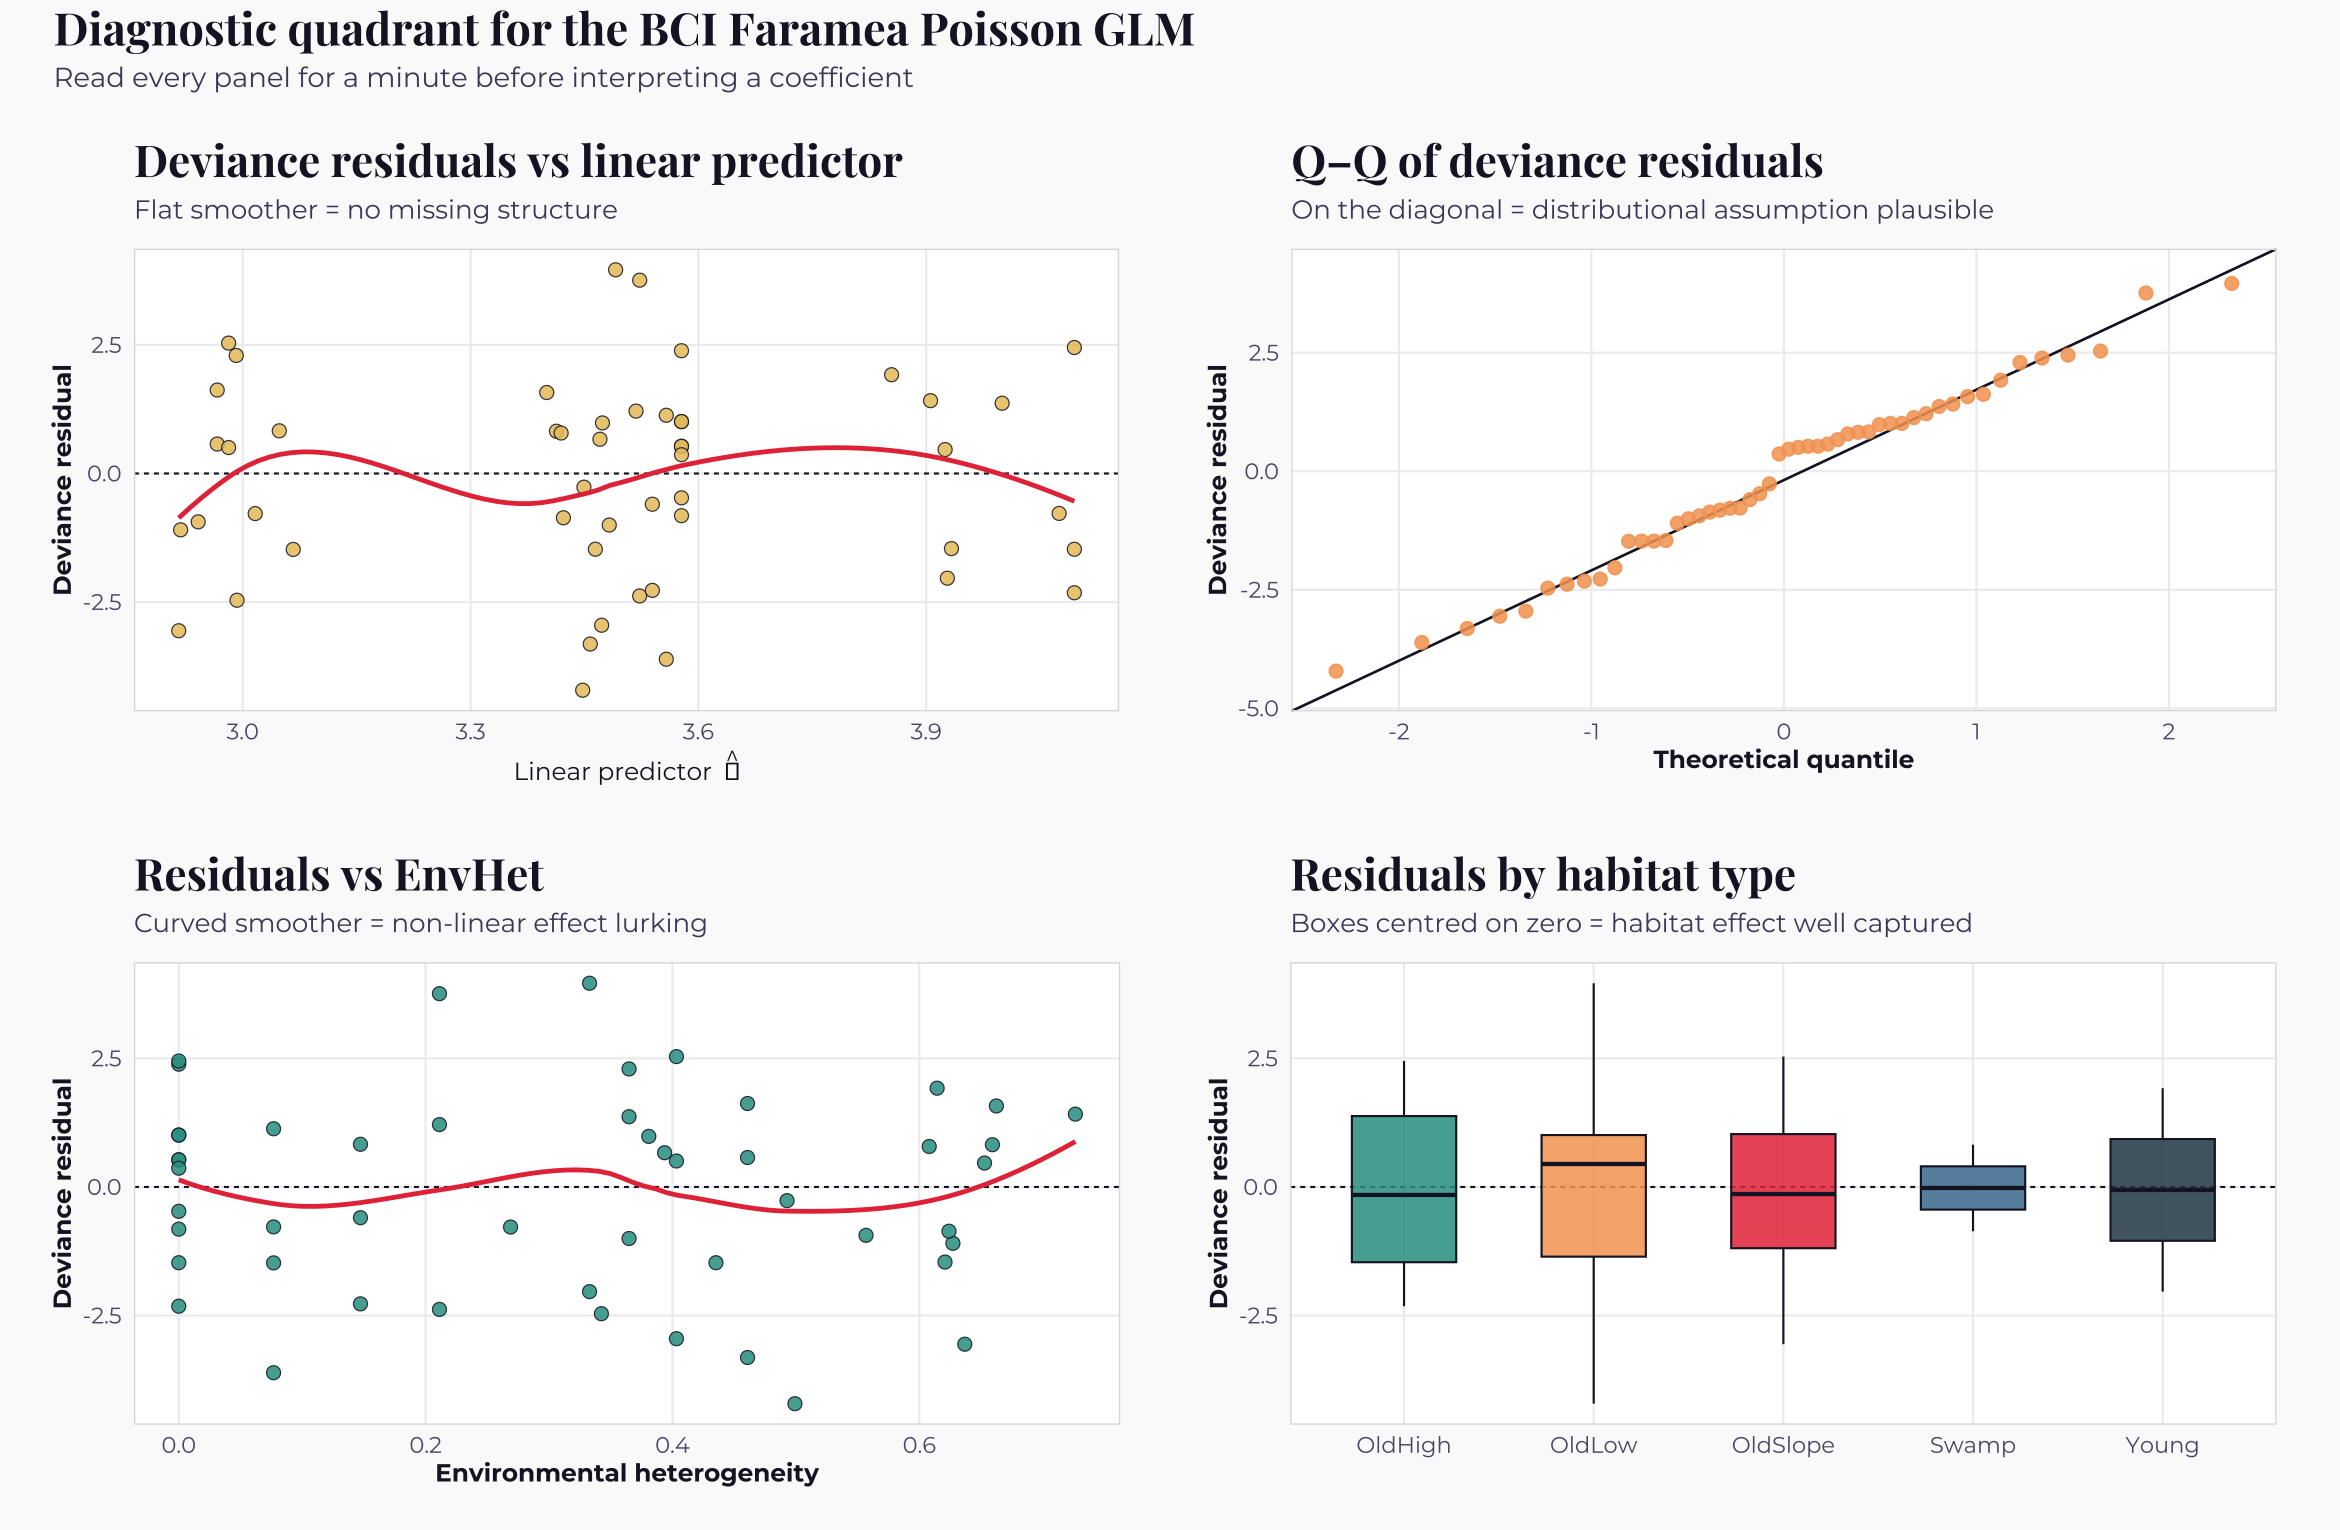

In [23]:
# Custom diagnostic quadrant for the BCI Faramea Poisson GLM
library(tidyverse); library(patchwork)

diag_df <- tibble(
  eta     = predict(fit_pois, type = "link"),
  mu      = fitted(fit_pois),
  dev_res = residuals(fit_pois, type = "deviance"),
  habitat = faramea$habitat,
  env_het = faramea$env_het
)

# D1 — residuals vs linear predictor
D1 <- ggplot(diag_df, aes(eta, dev_res)) +
  geom_hline(yintercept = 0, colour = "#1a1a2e", linetype = "22",
             linewidth = 0.4) +
  geom_point(shape = 21, fill = PalDiscrete[4], colour = "#1a1a2e",
             size = 2.4, stroke = 0.35, alpha = 0.85) +
  geom_smooth(method = "loess", formula = y ~ x, se = FALSE,
              colour = PalDiscrete[1], linewidth = 0.9) +
  labs(title    = "Deviance residuals vs linear predictor",
       subtitle = "Flat smoother = no missing structure",
       x = expression(paste("Linear predictor  ", hat(eta))),
       y = "Deviance residual") +
  theme_ml()

# D2 — Q-Q of deviance residuals
D2 <- ggplot(diag_df, aes(sample = dev_res)) +
  stat_qq_line(colour = "#1a1a2e", linewidth = 0.5) +
  stat_qq(colour = PalDiscrete[5], size = 2.2, alpha = 0.85) +
  labs(title    = "Q–Q of deviance residuals",
       subtitle = "On the diagonal = distributional assumption plausible",
       x = "Theoretical quantile",
       y = "Deviance residual") +
  theme_ml()

# D3 — residuals vs env_het
D3 <- ggplot(diag_df, aes(env_het, dev_res)) +
  geom_hline(yintercept = 0, colour = "#1a1a2e", linetype = "22",
             linewidth = 0.4) +
  geom_point(shape = 21, fill = PalDiscrete[3], colour = "#1a1a2e",
             size = 2.4, stroke = 0.35, alpha = 0.85) +
  geom_smooth(method = "loess", formula = y ~ x, se = FALSE,
              colour = PalDiscrete[1], linewidth = 0.9) +
  labs(title    = "Residuals vs EnvHet",
       subtitle = "Curved smoother = non-linear effect lurking",
       x = "Environmental heterogeneity",
       y = "Deviance residual") +
  theme_ml()

# D4 — residuals by habitat (categorical predictor → boxplot)
D4 <- ggplot(diag_df, aes(habitat, dev_res, fill = habitat)) +
  geom_hline(yintercept = 0, colour = "#1a1a2e", linetype = "22",
             linewidth = 0.4) +
  geom_boxplot(colour = "#1a1a2e", linewidth = 0.4,
               outlier.shape = 21, outlier.size = 2,
               alpha = 0.85, width = 0.55) +
  scale_fill_manual(values = PalDiscrete[c(3, 5, 1, 2, 7)],
                    guide = "none") +
  labs(title    = "Residuals by habitat type",
       subtitle = "Boxes centred on zero = habitat effect well captured",
       x = NULL,
       y = "Deviance residual") +
  theme_ml()

options(repr.plot.width = 13, repr.plot.height = 8.5)
(D1 | D2) / (D3 | D4) +
  plot_annotation(
    title    = "Diagnostic quadrant for the BCI Faramea Poisson GLM",
    subtitle = "Read every panel for a minute before interpreting a coefficient",
    theme = theme(plot.background = element_rect(fill = "#fafafa", colour = NA),
                  plot.title      = element_text(family = "playfair", face = "bold",
                                                  size = 18, colour = "#1a1a2e"),
                  plot.subtitle   = element_text(family = "mont", size = 11,
                                                  colour = "#4a4a6a")))


For a model that suffers from overdispersion, the diagnostic quadrant tells a story worth reading carefully. The residuals-versus-linear-predictor panel may show a flat-ish loess smoother but with residuals spreading more widely than they should under a Poisson model: the heavy tails in the Q-Q plot are a signature of variance exceeding the mean. The residuals-versus-EnvHet panel can reveal whether the linear term we have used for that covariate is adequate or whether a smooth would do better. The boxplot by habitat shows whether the categorical effect has been well captured (boxes centred on zero) or whether some habitat is systematically over- or under-predicted (a box clearly off-zero).

When you see an overdispersion signature in the Q-Q plot, the right next step is to refit as a negative binomial — exactly as we did in §6. Diagnostics for that NB refit will look noticeably tighter, particularly in the tails of the Q-Q plot. A well-fitted GLM on well-behaved data produces a quadrant where no panel shows systematic structure; when a smoother curves, it is telling you that a non-linear term is needed — a cue to reach for the generalised *additive* model of Part 4, where each predictor enters as a flexible smooth rather than a rigid line.

---
## The ecological GLM cheat-sheet

Every working ecologist should be able to match a response variable to a sensible GLM family within a few seconds. The table below summarises the most common pairings. Pin it above your desk until the mapping becomes second nature.

| Ecological response | Likely family | Link | R syntax |
|---|---|---|---|
| Continuous, symmetric (e.g. pH, standardised indices) | Gaussian | identity | `glm(y ~ x, family = gaussian)` or just `lm(y ~ x)` |
| Counts per unit area or effort | Poisson → check dispersion | log | `glm(y ~ x + offset(log(effort)), family = poisson)` |
| Overdispersed counts | Negative binomial | log | `MASS::glm.nb(y ~ x)` |
| Counts with excess zeros | Zero-inflated Poisson / NB | log | `pscl::zeroinfl(y ~ x, dist = "negbin")` |
| Presence / absence | Binomial (Bernoulli) | logit | `glm(y ~ x, family = binomial)` |
| Proportion  $k/n$ with known $n$ | Binomial | logit | `glm(cbind(k, n-k) ~ x, family = binomial)` |
| Strictly positive continuous (biomass, home range) | Gamma | log | `glm(y ~ x, family = Gamma(link = "log"))` |
| Positive continuous with exact zeros | Tweedie | log | `statmod::tweedie(var.power = 1.5)` |
| Continuous on $[0, 1]$ (proportions without denominator) | Beta | logit | `betareg::betareg(y ~ x)` |

Two further points are worth internalising. First, GLMs are not the last word — they assume independence of observations, and ecological data rarely provide it. When observations are nested (tadpoles within ponds within catchments) or spatially autocorrelated (plots along a transect), you need a **generalised linear mixed model** (GLMM) or a spatial extension. Packages like `lme4`, `glmmTMB`, and `INLA` extend the GLM framework in exactly this direction. Second, the assumption that the linear predictor is truly *linear* in the covariates is often the first to fail in practice. When a predictor's effect is humped or threshold-like, GAMs (notebook 04) are the principled generalisation.

## Takeaways

Nelder and Wedderburn's 1972 unification made it possible to treat what looked like a zoo of regression methods as a single family, fit by a single algorithm, interpreted through a small vocabulary of link functions and response distributions. The core idea — linear predictor, response distribution, link function — is a piece of mathematical architecture that will repay you every week of your career. The Poisson and gamma GLMs you fitted today are the workhorses of ecological count and biomass modelling, and the overdispersion diagnostic you learned to run will catch silent errors in more papers than you would like to imagine.

---
### Exercises before Part 4

1. The BCI dataset has 224 other tree species besides *Faramea occidentalis*. Pick another common one — try `Trichilia.tuberculata`, `Alseis.blackiana`, or `Beilschmiedia.pendula` — and refit the Poisson and negative-binomial models on its counts. Does the same habitat pattern emerge, or does this species prefer different conditions? What does that tell you ecologically?

2. The BCI environmental data include `Precipitation` and `Elevation`, but on the 50-ha plot these are essentially constant. Use `BCI.env$UTM.NS` (north-south position) as a continuous predictor of *Faramea* count instead — does the species show a north-south gradient across the 1-km plot?

3. Compute *species richness* (the number of species with at least one individual) for each of the 50 BCI plots: `rich <- rowSums(BCI > 0)`. Fit `glm(rich ~ habitat + env_het, family = poisson, data = ...)`. Is richness overdispersed? Compare the Poisson and negative-binomial fits.

4. Refit the black-cherry tree volume model with `family = Gamma(link = "inverse")` instead of `log`. Compare the two fits with AIC. The inverse link gives a model where $1/\mathbb{E}[V]$ is linear in $\log(\text{Girth})$ and $\log(\text{Height})$ — does this fit better or worse than the log link, and what is the geometric meaning of the difference?

5. *Conceptual.* A colleague proposes to model **species richness** using `lm()` with $\log(\text{richness})$ as the response. Give two reasons a Poisson GLM is preferable, and one scenario in which the log-lm approach might be defensible.

---

### Coming up in Part 4

We relax the remaining assumption that each predictor's effect is a straight line. The **generalised additive model** replaces rigid slopes with data-adaptive smooth functions, giving us the flexibility to capture humps, thresholds, and saturations without losing the interpretability of classical regression. The Poisson framework you just learned will carry over intact — only the linear-in-$x$ part changes.